In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Time series diagnostics
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Prophet
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print(sys.executable)

Importing plotly failed. Interactive plots will not work.


C:\Users\lamby\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [2]:
univariate_city_path = r"C:\Users\lamby\Downloads\Final Code 2\Final Code\Miami_and_Hialeah_alltraps.xlsx"

df_city = pd.read_excel(univariate_city_path)

df_city["Date_Submitted"] = pd.to_datetime(df_city["Date_Submitted"])
df_city = df_city.sort_values("Date_Submitted").reset_index(drop=True)

df_city.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,City
0,2016-01-05,2,E5,Miami
1,2016-01-05,3,E1,Miami
2,2016-01-12,2,KB1,Miami
3,2016-01-12,1,E2,Miami
4,2016-01-12,6,VK1,Miami


In [3]:
df_hialeah = df_city[df_city["City"] == "Hialeah"].copy()

def weekly_aggregate(df, date_col, value_col):
    """
    Aggregates mosquito counts to weekly frequency.
    Missing weeks are filled with zero because no recorded mosquitoes
    should represent zero observed count for that week.
    """
    ts = (
        df.set_index(date_col)
        .resample("W")[value_col]
        .sum()
        .to_frame(name="mosquito_count")
    )
    
    ts["mosquito_count"] = ts["mosquito_count"].fillna(0)
    return ts

ts_hialeah = weekly_aggregate(
    df_hialeah,
    date_col="Date_Submitted",
    value_col="Cx_quinquefasciatus_fem"
)

print("Hialeah weekly series shape:", ts_hialeah.shape)
ts_hialeah.head()

Hialeah weekly series shape: (273, 1)


,mosquito_count
Date_Submitted,
2016-08-21,1
2016-08-28,6
2016-09-04,1
2016-09-11,17
2016-09-18,46


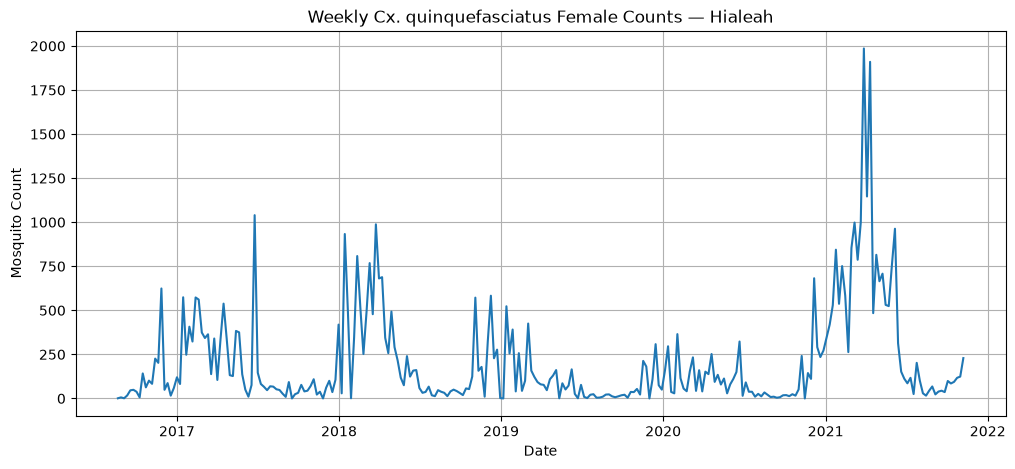

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(ts_hialeah.index, ts_hialeah["mosquito_count"])
plt.title("Weekly Cx. quinquefasciatus Female Counts — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.show()

In [5]:
ts_series = ts_hialeah["mosquito_count"]

train_size = int(len(ts_series) * 0.8)

train_series = ts_series.iloc[:train_size]
test_series = ts_series.iloc[train_size:]

print("Train size:", len(train_series))
print("Test size:", len(test_series))
print("Train period:", train_series.index.min(), "to", train_series.index.max())
print("Test period:", test_series.index.min(), "to", test_series.index.max())


def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    nrmse = rmse / np.mean(y_true) if np.mean(y_true) != 0 else np.nan

    nonzero_mask = y_true != 0
    if np.sum(nonzero_mask) > 0:
        mape = np.mean(
            np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denominator != 0
    if np.sum(smape_mask) > 0:
        smape = np.mean(
            np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denominator[smape_mask]
        ) * 100
    else:
        smape = np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "nRMSE": nrmse,
        "MAPE": mape,
        "SMAPE": smape
    }


model_results = []

def add_result(model_name, y_true, y_pred):
    metrics = compute_metrics(y_true, y_pred)
    model_results.append({
        "City": "Hialeah",
        "Model": model_name,
        **metrics
    })
    return metrics

Train size: 218
Test size: 55
Train period: 2016-08-21 00:00:00 to 2020-10-18 00:00:00
Test period: 2020-10-25 00:00:00 to 2021-11-07 00:00:00


In [6]:
def naive_forecast(train):
    return train.iloc[-1]

def seasonal_naive_forecast(train, season_length=52):
    if len(train) < season_length:
        return train.iloc[-1]
    return train.iloc[-season_length]

def rolling_mean_forecast(train, window=4):
    return train.iloc[-window:].mean()


def evaluate_expanding_baseline(ts, model_fn, initial_train_size, **kwargs):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        pred = model_fn(train, **kwargs)

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


INITIAL_TRAIN_SIZE = 52

baseline_specs = [
    ("Naive", naive_forecast, {}),
    ("Seasonal Naive", seasonal_naive_forecast, {"season_length": 52}),
    ("Rolling Mean", rolling_mean_forecast, {"window": 4})
]

for name, fn, kwargs in baseline_specs:
    y_true, y_pred = evaluate_expanding_baseline(
        ts_series,
        fn,
        initial_train_size=INITIAL_TRAIN_SIZE,
        **kwargs
    )
    
    metrics = add_result(name, y_true, y_pred)
    print(name, metrics)

baseline_df = pd.DataFrame(model_results)
baseline_df

Naive {'RMSE': np.float64(231.17546371235946), 'MAE': 133.66968325791856, 'R2': 0.38963799850061087, 'nRMSE': np.float64(1.1218167291825445), 'MAPE': np.float64(490.2417675188666), 'SMAPE': np.float64(77.1297858796008)}
Seasonal Naive {'RMSE': np.float64(332.5024614613072), 'MAE': 194.3393665158371, 'R2': -0.26268128312946426, 'nRMSE': np.float64(1.6135225502382171), 'MAPE': np.float64(610.0708834443078), 'SMAPE': np.float64(101.63394094216238)}
Rolling Mean {'RMSE': np.float64(200.7222747008562), 'MAE': 114.23755656108597, 'R2': 0.5398545271010322, 'nRMSE': np.float64(0.9740376511547411), 'MAPE': np.float64(492.75439993094625), 'SMAPE': np.float64(65.81807972425763)}


,City,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Hialeah,Naive,231.175464,133.669683,0.389638,1.121817,490.241768,77.129786
1,Hialeah,Seasonal Naive,332.502461,194.339367,-0.262681,1.613523,610.070883,101.633941
2,Hialeah,Rolling Mean,200.722275,114.237557,0.539855,0.974038,492.754400,65.818080


In [7]:
univariate_city_path = r"C:\Users\lamby\Downloads\Final Code 2\Final Code\Miami_and_Hialeah_alltraps.xlsx"

df_city = pd.read_excel(univariate_city_path)

df_city["Date_Submitted"] = pd.to_datetime(df_city["Date_Submitted"])
df_city = df_city.sort_values("Date_Submitted").reset_index(drop=True)

df_city.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,City
0,2016-01-05,2,E5,Miami
1,2016-01-05,3,E1,Miami
2,2016-01-12,2,KB1,Miami
3,2016-01-12,1,E2,Miami
4,2016-01-12,6,VK1,Miami


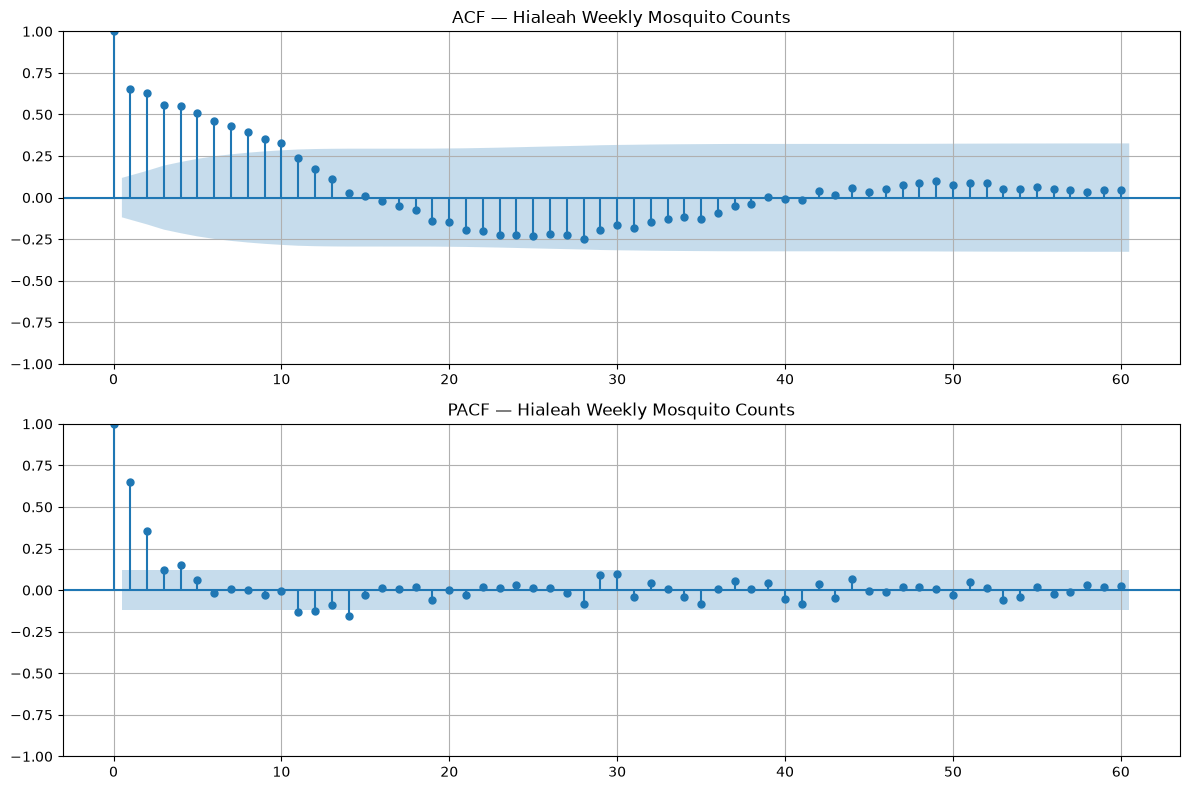

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(ts_series, lags=60, ax=axes[0])
axes[0].set_title("ACF — Hialeah Weekly Mosquito Counts")

plot_pacf(ts_series, lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Hialeah Weekly Mosquito Counts")

plt.tight_layout()
plt.show()

In [9]:
def stationarity_tests(ts):
    """
    Runs ADF and KPSS tests.
    ADF null hypothesis: series is non-stationary.
    KPSS null hypothesis: series is stationary.
    """
    ts_clean = ts.dropna()

    adf_result = adfuller(ts_clean, autolag="AIC")
    kpss_result = kpss(ts_clean, regression="c", nlags="auto")

    return pd.DataFrame({
        "Test": ["ADF", "KPSS"],
        "Statistic": [adf_result[0], kpss_result[0]],
        "p-value": [adf_result[1], kpss_result[1]]
    })

stationarity_tests(ts_series)

C:\Users\lamby\AppData\Local\Temp\ipykernel_1628\2365130481.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts_clean, regression="c", nlags="auto")


,Test,Statistic,p-value
0,ADF,-3.360997,0.012363
1,KPSS,0.180378,0.100000


In [10]:
def residual_diagnostics(residuals, fitted_values=None, title="Residual Diagnostics"):
    residuals = pd.Series(residuals).dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals Over Time")

    if fitted_values is not None:
        fitted_values = np.array(fitted_values)
        min_len = min(len(fitted_values), len(residuals))
        axes[0, 1].scatter(fitted_values[-min_len:], residuals[-min_len:])
        axes[0, 1].axhline(0, linestyle="--")
        axes[0, 1].set_title("Residuals vs Fitted")
    else:
        axes[0, 1].hist(residuals, bins=25)
        axes[0, 1].set_title("Residual Distribution")

    plot_acf(residuals, ax=axes[1, 0])
    axes[1, 0].set_title("ACF of Residuals")

    qqplot(residuals, line="s", ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print("Ljung-Box Test:")
    display(acorr_ljungbox(residuals, lags=[10, 20], return_df=True))

## ARIMA

In [11]:
def tune_arima(train, p_values, d_values, q_values):
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)

                try:
                    model = ARIMA(train, order=order)
                    fitted = model.fit()

                    results.append({
                        "order": order,
                        "AIC": fitted.aic,
                        "BIC": fitted.bic
                    })

                except Exception:
                    continue

    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


arima_tuning_results = tune_arima(
    train_series,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5)
)

arima_tuning_results.head(10)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages

,order,AIC,BIC
0,"(4, 0, 3)",18.000000,48.460456
1,"(2, 1, 3)",2827.852869,2848.132254
2,"(4, 1, 3)",2829.540452,2856.579631
3,"(3, 1, 3)",2830.001655,2853.660936
4,"(2, 1, 4)",2830.057562,2853.716844
5,"(3, 1, 4)",2830.361941,2857.401120
6,"(4, 0, 4)",2830.860433,2864.705384
7,"(0, 1, 1)",2831.095773,2837.855568
8,"(4, 1, 0)",2831.732455,2848.631942
9,"(0, 1, 4)",2831.998051,2848.897538


Best ARIMA order: (4, 0, 3)
{'RMSE': np.float64(509.74615289075535), 'MAE': 328.9681153897492, 'R2': -0.3599000271749211, 'nRMSE': np.float64(1.2409719550722178), 'MAPE': np.float64(130.83971013698056), 'SMAPE': np.float64(97.24369352415371)}


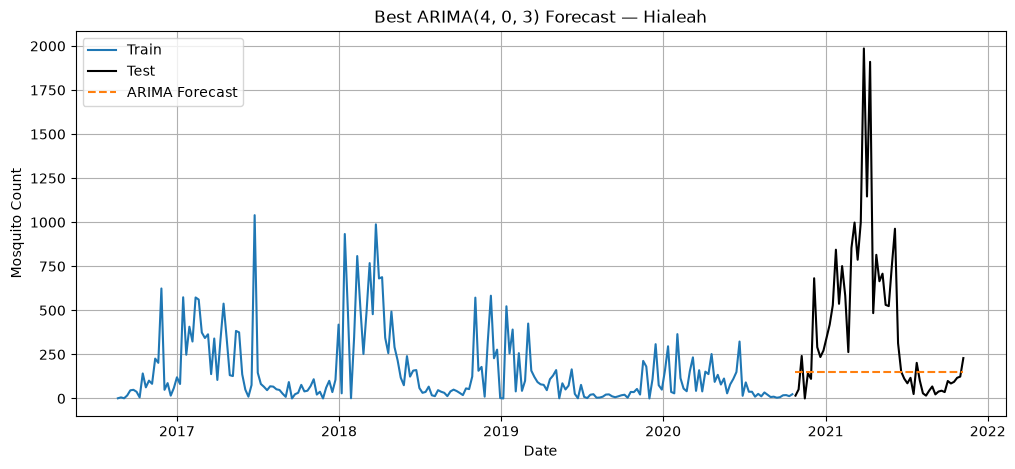

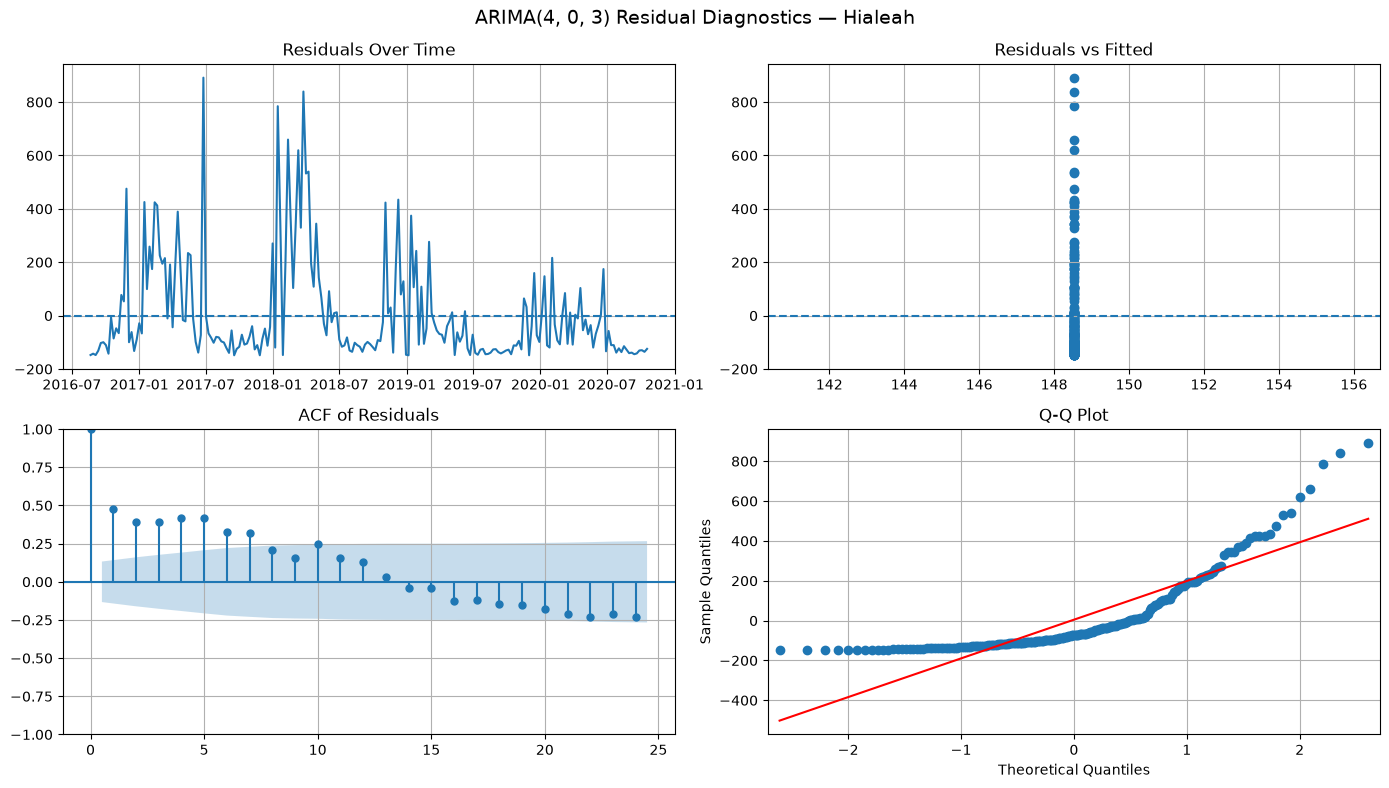

Ljung-Box Test:


,lb_stat,lb_pvalue
10,274.632166,3.530204e-53
20,309.929748,7.546592e-54


In [12]:
best_arima_order = arima_tuning_results.iloc[0]["order"]
print("Best ARIMA order:", best_arima_order)

best_arima = ARIMA(train_series, order=best_arima_order).fit()

arima_forecast = best_arima.forecast(steps=len(test_series))
arima_forecast.index = test_series.index
arima_forecast = np.maximum(arima_forecast, 0)

metrics = add_result(f"ARIMA{best_arima_order}", test_series, arima_forecast)
print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", linestyle="--")
plt.title(f"Best ARIMA{best_arima_order} Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    best_arima.resid,
    fitted_values=best_arima.fittedvalues,
    title=f"ARIMA{best_arima_order} Residual Diagnostics — Hialeah"
)

In [13]:
log_train = np.log1p(train_series)
log_test = np.log1p(test_series)

log_arima_tuning_results = tune_arima(
    log_train,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5)
)

log_arima_tuning_results.head(10)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages

,order,AIC,BIC
0,"(2, 0, 3)",716.890344,740.581810
1,"(2, 0, 4)",717.363593,744.439554
2,"(3, 0, 2)",717.391065,741.082530
3,"(3, 0, 3)",717.985281,745.061242
4,"(3, 0, 4)",720.319597,750.780053
5,"(4, 0, 4)",720.654425,754.499376
6,"(4, 0, 3)",720.948012,751.408468
7,"(1, 1, 3)",723.942593,740.842080
8,"(2, 1, 2)",724.414719,741.314206
9,"(0, 1, 3)",724.651907,738.171496


Best log-ARIMA order: (2, 0, 3)
{'RMSE': np.float64(511.5576129273632), 'MAE': 330.9560126156916, 'R2': -0.3695824213599821, 'nRMSE': np.float64(1.2453819365706877), 'MAPE': np.float64(70.27500012763156), 'SMAPE': np.float64(107.90481087879328)}


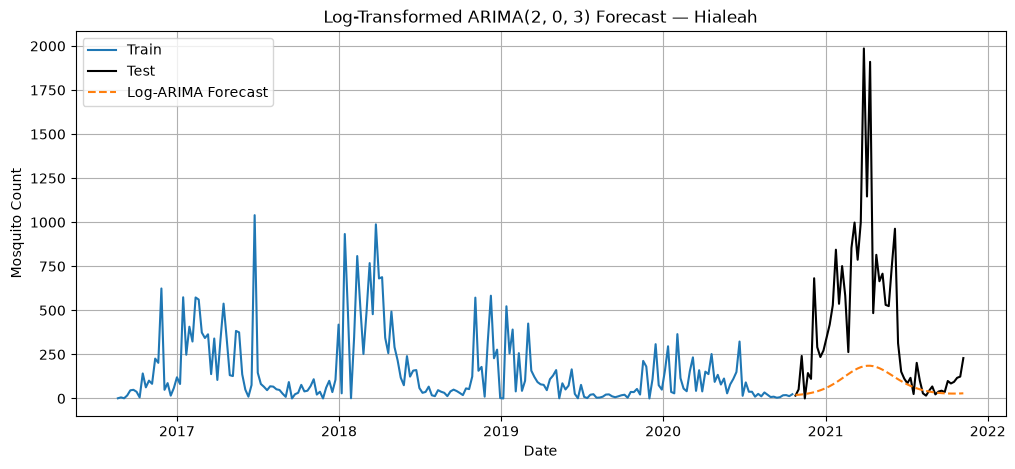

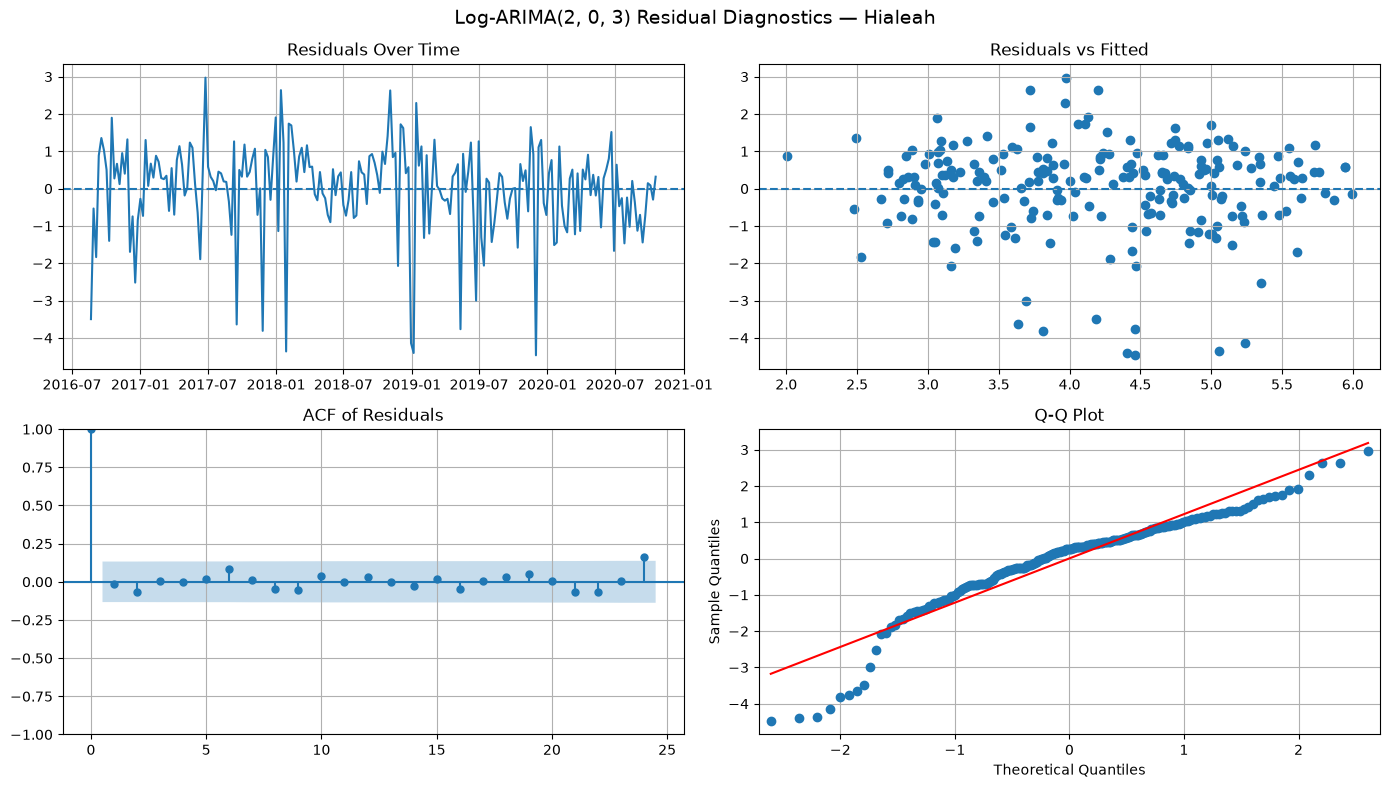

Ljung-Box Test:


,lb_stat,lb_pvalue
10,4.020217,0.94643
20,5.904785,0.99902


In [14]:
best_log_arima_order = log_arima_tuning_results.iloc[0]["order"]
print("Best log-ARIMA order:", best_log_arima_order)

best_log_arima = ARIMA(log_train, order=best_log_arima_order).fit()

log_forecast = best_log_arima.forecast(steps=len(test_series))
log_forecast.index = test_series.index

log_arima_forecast_original_scale = np.expm1(log_forecast)
log_arima_forecast_original_scale = np.maximum(log_arima_forecast_original_scale, 0)

metrics = add_result(
    f"Log-ARIMA{best_log_arima_order}",
    test_series,
    log_arima_forecast_original_scale
)

print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    log_arima_forecast_original_scale.index,
    log_arima_forecast_original_scale,
    label="Log-ARIMA Forecast",
    linestyle="--"
)
plt.title(f"Log-Transformed ARIMA{best_log_arima_order} Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    best_log_arima.resid,
    fitted_values=best_log_arima.fittedvalues,
    title=f"Log-ARIMA{best_log_arima_order} Residual Diagnostics — Hialeah"
)

In [15]:
def rolling_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        try:
            model = ARIMA(train, order=order)
            fitted = model.fit()
            pred = fitted.forecast(steps=1).iloc[0]
            pred = max(pred, 0)
        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


y_true_roll_arima, y_pred_roll_arima = rolling_arima_forecast(
    ts_series,
    order=best_arima_order,
    initial_train_size=INITIAL_TRAIN_SIZE
)

metrics_roll_arima = compute_metrics(y_true_roll_arima, y_pred_roll_arima)
print(metrics_roll_arima)

add_result(
    f"Rolling ARIMA{best_arima_order}",
    y_true_roll_arima,
    y_pred_roll_arima
)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages

{'RMSE': np.float64(207.65118500113567), 'MAE': 130.18315745447052, 'R2': 0.5075378676199594, 'nRMSE': np.float64(1.0076613210937373), 'MAPE': np.float64(572.2779384551167), 'SMAPE': np.float64(79.13620938742729)}


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'RMSE': np.float64(207.65118500113567),
 'MAE': 130.18315745447052,
 'R2': 0.5075378676199594,
 'nRMSE': np.float64(1.0076613210937373),
 'MAPE': np.float64(572.2779384551167),
 'SMAPE': np.float64(79.13620938742729)}

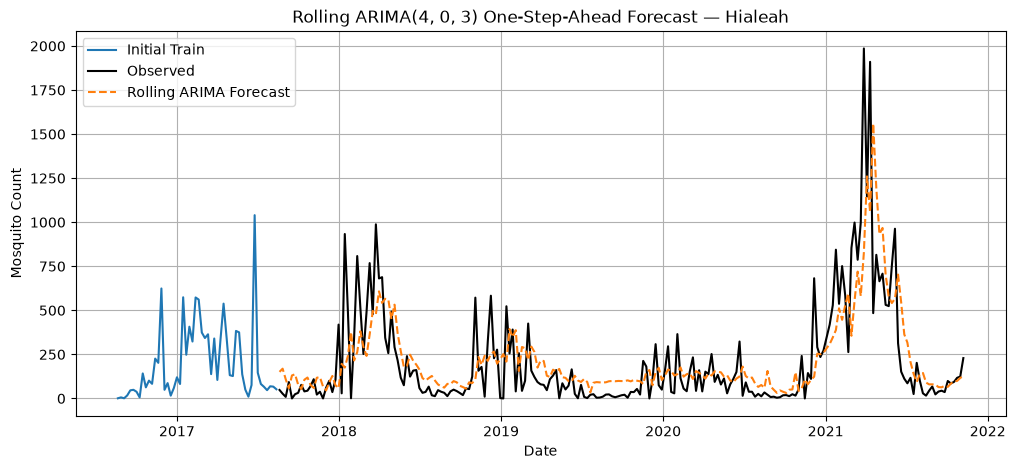

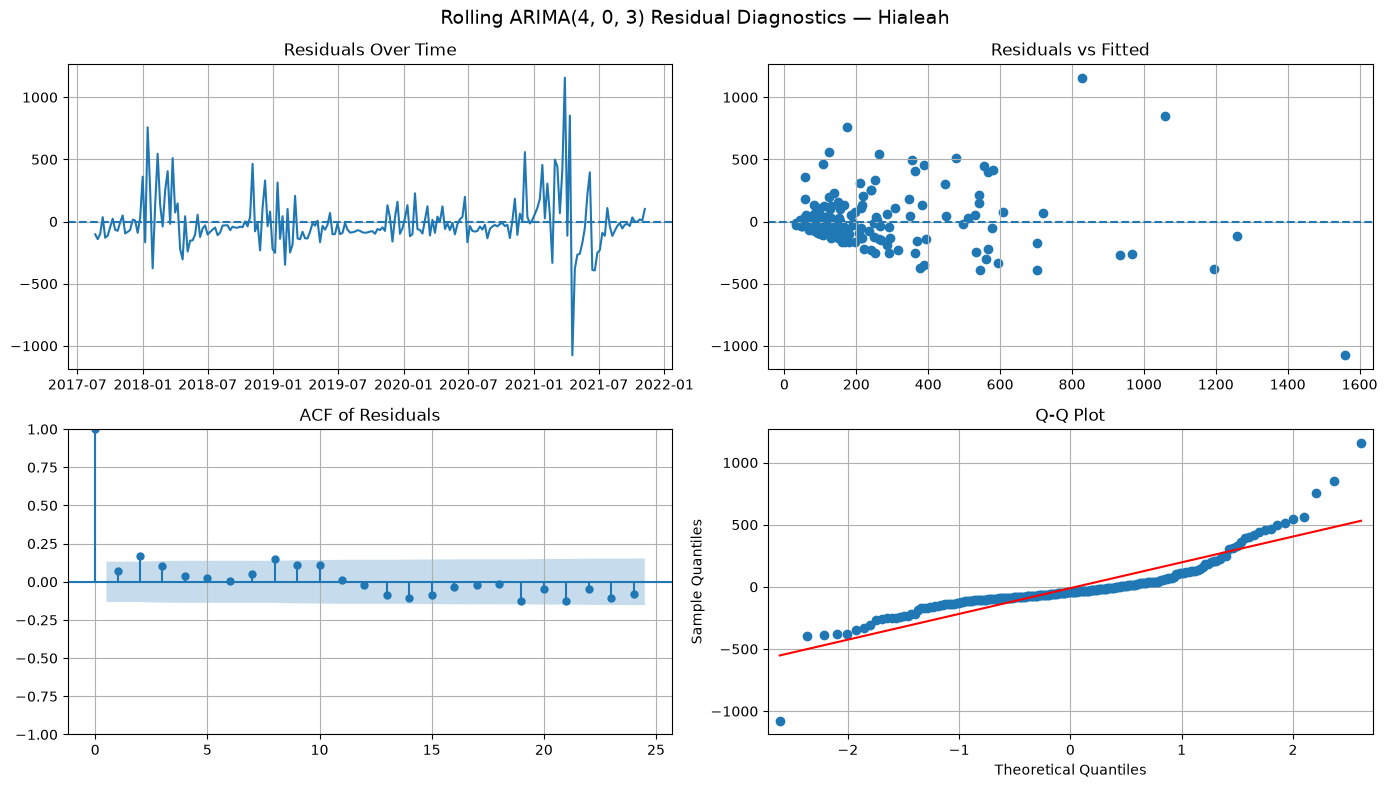

Ljung-Box Test:


,lb_stat,lb_pvalue
10,22.079950,0.014702
20,33.151066,0.032475


,lb_stat,lb_pvalue
10,22.079950,0.014702
20,33.151066,0.032475
30,46.089771,0.030467


In [16]:
rolling_start_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_arima_true = pd.Series(
    y_true_roll_arima,
    index=rolling_start_index,
    name="True"
)

rolling_arima_pred = pd.Series(
    y_pred_roll_arima,
    index=rolling_start_index,
    name="Rolling ARIMA Forecast"
)

rolling_arima_residuals = rolling_arima_true - rolling_arima_pred

plt.figure(figsize=(12, 5))

plt.plot(
    ts_series.index[:INITIAL_TRAIN_SIZE],
    ts_series.iloc[:INITIAL_TRAIN_SIZE],
    label="Initial Train"
)

plt.plot(
    rolling_arima_true.index,
    rolling_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_arima_pred.index,
    rolling_arima_pred,
    label="Rolling ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling ARIMA{best_arima_order} One-Step-Ahead Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    rolling_arima_residuals,
    fitted_values=rolling_arima_pred,
    title=f"Rolling ARIMA{best_arima_order} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        rolling_arima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [17]:
def rolling_log_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        log_train = np.log1p(train)

        try:
            model = ARIMA(log_train, order=order)
            fitted = model.fit()

            log_pred = fitted.forecast(steps=1).iloc[0]
            pred = np.expm1(log_pred)
            pred = max(pred, 0)

        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


y_true_roll_log_arima, y_pred_roll_log_arima = rolling_log_arima_forecast(
    ts_series,
    order=best_arima_order,
    initial_train_size=INITIAL_TRAIN_SIZE
)

metrics_roll_log_arima = compute_metrics(
    y_true_roll_log_arima,
    y_pred_roll_log_arima
)

print(metrics_roll_log_arima)

add_result(
    f"Rolling Log-ARIMA{best_arima_order}",
    y_true_roll_log_arima,
    y_pred_roll_log_arima
)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages

{'RMSE': np.float64(242.31699692834675), 'MAE': 133.5104211648643, 'R2': 0.3293873062448339, 'nRMSE': np.float64(1.1758828404805373), 'MAPE': np.float64(321.1610967659346), 'SMAPE': np.float64(80.0867676153484)}


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'RMSE': np.float64(242.31699692834675),
 'MAE': 133.5104211648643,
 'R2': 0.3293873062448339,
 'nRMSE': np.float64(1.1758828404805373),
 'MAPE': np.float64(321.1610967659346),
 'SMAPE': np.float64(80.0867676153484)}

In [18]:
rolling_log_arima_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_log_arima_true = pd.Series(
    y_true_roll_log_arima,
    index=rolling_log_arima_index,
    name="Observed"
)

rolling_log_arima_pred = pd.Series(
    y_pred_roll_log_arima,
    index=rolling_log_arima_index,
    name="Rolling Log-ARIMA Forecast"
)

rolling_log_arima_residuals = rolling_log_arima_true - rolling_log_arima_pred

In [19]:
arima_results = []

def add_arima_result(model_name, order, y_true, y_pred, fitted_model=None):
    metrics = compute_metrics(y_true, y_pred)

    if fitted_model is not None:
        aic = fitted_model.aic
        bic = fitted_model.bic
    else:
        aic = np.nan
        bic = np.nan

    arima_results.append({
        "Model": model_name,
        "Order": str(order),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "nRMSE": metrics["nRMSE"],
        "MAPE": metrics["MAPE"],
        "SMAPE": metrics["SMAPE"],
        "AIC": aic,
        "BIC": bic
    })


add_arima_result(
    model_name="ARIMA One-Shot",
    order=best_arima_order,
    y_true=test_series,
    y_pred=arima_forecast,
    fitted_model=best_arima
)

add_arima_result(
    model_name="Log-ARIMA One-Shot",
    order=best_log_arima_order,
    y_true=test_series,
    y_pred=log_arima_forecast_original_scale,
    fitted_model=best_log_arima
)

add_arima_result(
    model_name="Rolling ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_arima,
    y_pred=y_pred_roll_arima,
    fitted_model=None
)

add_arima_result(
    model_name="Rolling Log-ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_log_arima,
    y_pred=y_pred_roll_log_arima,
    fitted_model=None
)

arima_results_df = pd.DataFrame(arima_results)
arima_results_df = arima_results_df.sort_values("RMSE").reset_index(drop=True)

arima_results_df

,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Rolling ARIMA,"(4, 0, 3)",207.651185,130.183157,0.507538,1.007661,572.277938,79.136209,NaN,NaN
1,Rolling Log-ARIMA,"(4, 0, 3)",242.316997,133.510421,0.329387,1.175883,321.161097,80.086768,NaN,NaN
2,ARIMA One-Shot,"(4, 0, 3)",509.746153,328.968115,-0.359900,1.240972,130.839710,97.243694,18.000000,48.460456
3,Log-ARIMA One-Shot,"(2, 0, 3)",511.557613,330.956013,-0.369582,1.245382,70.275000,107.904811,716.890344,740.581810


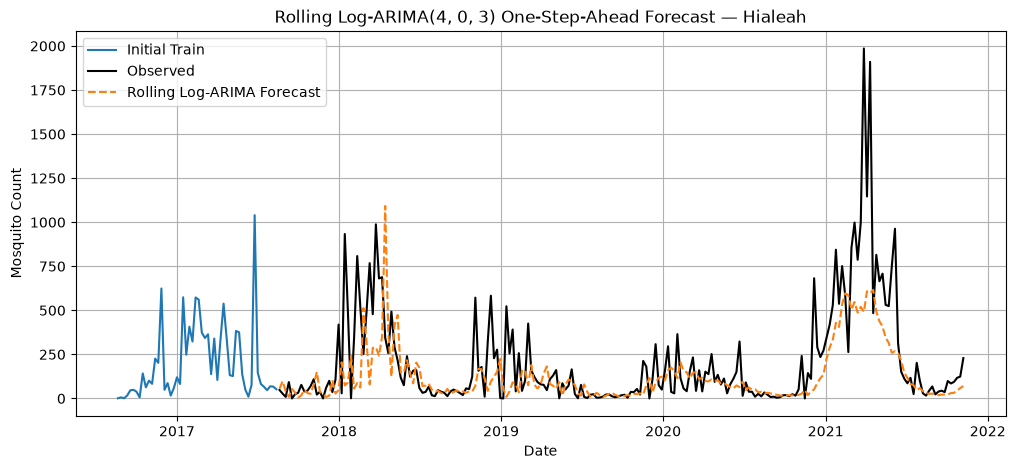

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    ts_series.index[:INITIAL_TRAIN_SIZE],
    ts_series.iloc[:INITIAL_TRAIN_SIZE],
    label="Initial Train"
)

plt.plot(
    rolling_log_arima_true.index,
    rolling_log_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_log_arima_pred.index,
    rolling_log_arima_pred,
    label="Rolling Log-ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling Log-ARIMA{best_arima_order} One-Step-Ahead Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

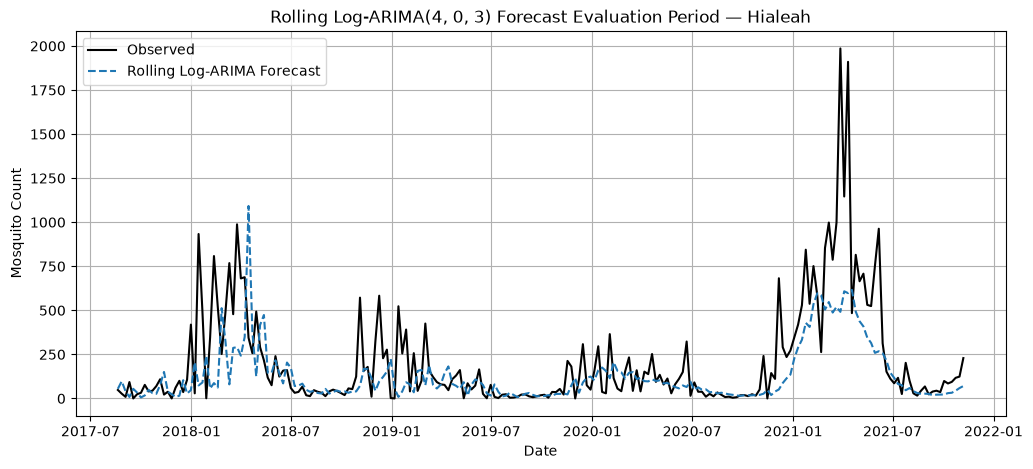

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    rolling_log_arima_true.index,
    rolling_log_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_log_arima_pred.index,
    rolling_log_arima_pred,
    label="Rolling Log-ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling Log-ARIMA{best_arima_order} Forecast Evaluation Period — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

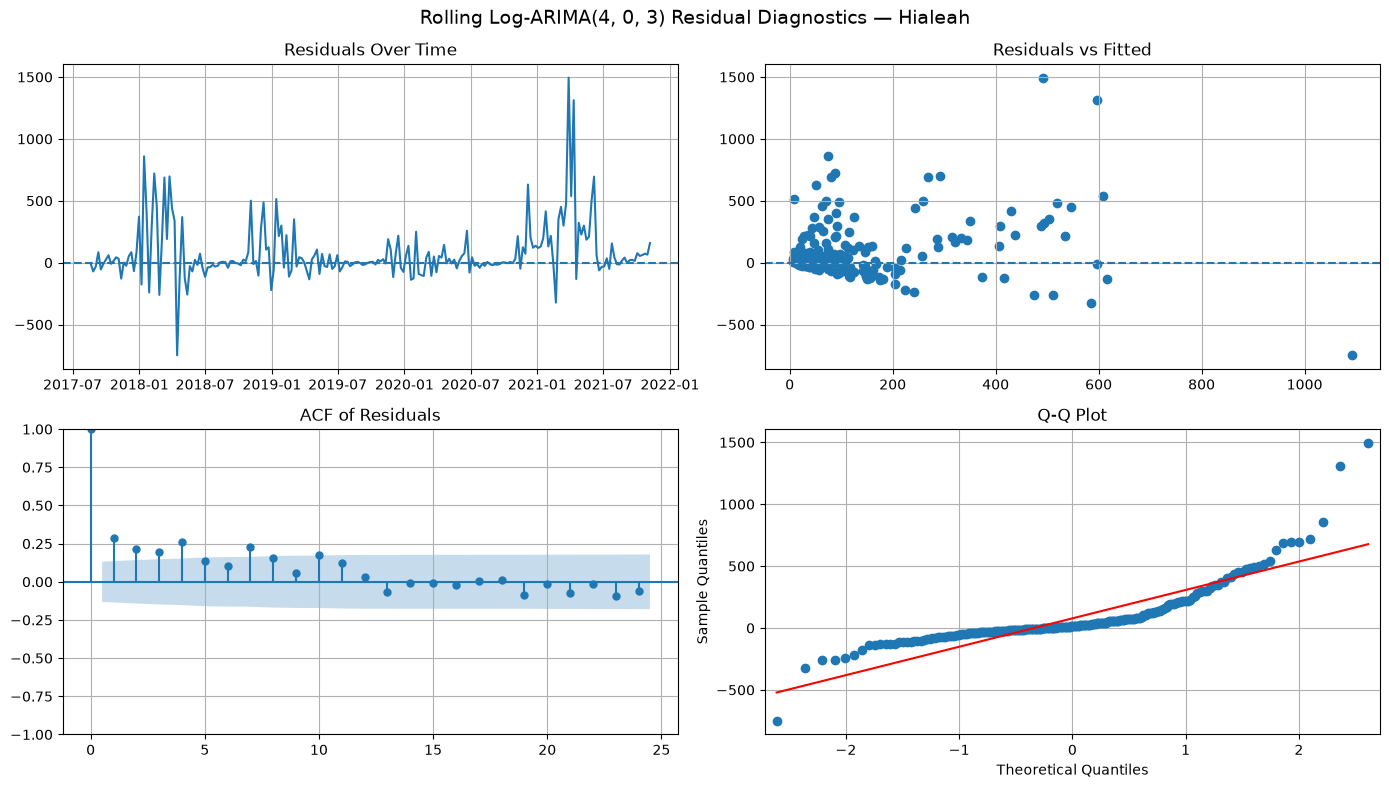

Ljung-Box Test:


,lb_stat,lb_pvalue
10,86.196489,3.030564e-14
20,93.069715,2.143647e-11


In [22]:
residual_diagnostics(
    rolling_log_arima_residuals,
    fitted_values=rolling_log_arima_pred,
    title=f"Rolling Log-ARIMA{best_arima_order} Residual Diagnostics — Hialeah"
)

In [23]:
display(
    acorr_ljungbox(
        rolling_log_arima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

,lb_stat,lb_pvalue
10,86.196489,3.030564e-14
20,93.069715,2.143647e-11
30,104.196917,3.990995e-10


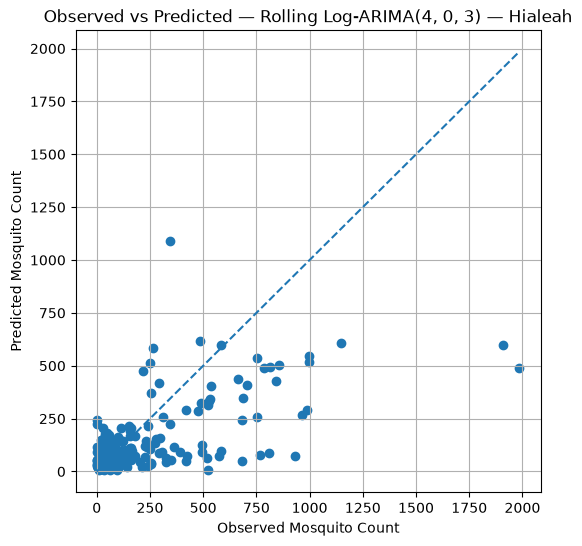

In [24]:
plt.figure(figsize=(6, 6))

plt.scatter(rolling_log_arima_true, rolling_log_arima_pred)

min_val = min(rolling_log_arima_true.min(), rolling_log_arima_pred.min())
max_val = max(rolling_log_arima_true.max(), rolling_log_arima_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title(f"Observed vs Predicted — Rolling Log-ARIMA{best_arima_order} — Hialeah")
plt.xlabel("Observed Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.show()

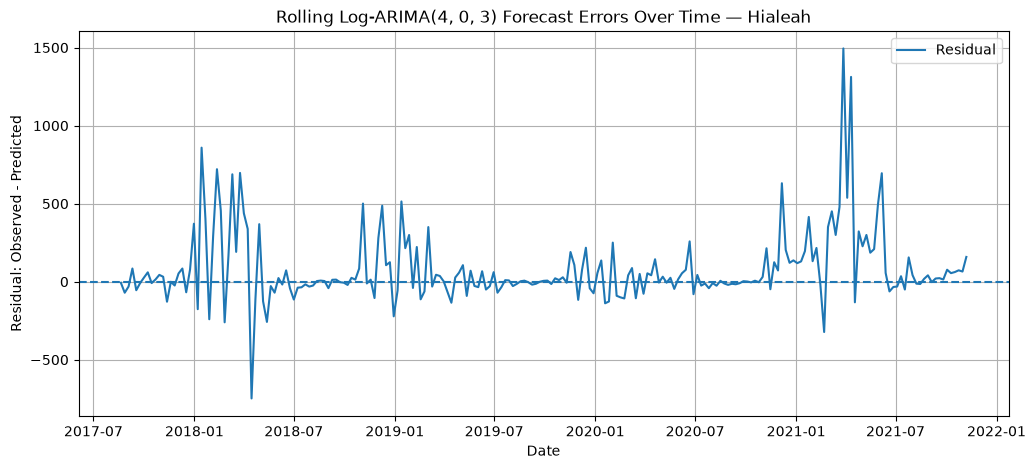

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    rolling_log_arima_residuals.index,
    rolling_log_arima_residuals,
    label="Residual"
)

plt.axhline(0, linestyle="--")

plt.title(f"Rolling Log-ARIMA{best_arima_order} Forecast Errors Over Time — Hialeah")
plt.xlabel("Date")
plt.ylabel("Residual: Observed - Predicted")
plt.legend()
plt.show()

In [26]:
arima_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Rolling ARIMA,"(4, 0, 3)",207.65,130.18,0.508,1.008,572.28,79.14,nan,nan
1,Rolling Log-ARIMA,"(4, 0, 3)",242.32,133.51,0.329,1.176,321.16,80.09,nan,nan
2,ARIMA One-Shot,"(4, 0, 3)",509.75,328.97,-0.360,1.241,130.84,97.24,18.00,48.46
3,Log-ARIMA One-Shot,"(2, 0, 3)",511.56,330.96,-0.370,1.245,70.28,107.90,716.89,740.58


In [27]:
add_arima_result(
    model_name="Rolling ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_arima,
    y_pred=y_pred_roll_arima,
    fitted_model=None
)

add_arima_result(
    model_name="Rolling Log-ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_log_arima,
    y_pred=y_pred_roll_log_arima,
    fitted_model=None
)

In [28]:
import itertools
import time

## SARIMA

In [29]:
def tune_sarima_small(train, seasonal_period=52):
    """
    Small SARIMA tuning grid designed to run in reasonable time.
    """
    
    candidate_orders = [
        (1, 0, 0),
        (1, 0, 1),
        (2, 0, 1),
        (3, 0, 1),
        (3, 0, 2),
        (3, 0, 4),
    ]
    
    candidate_seasonal_orders = [
        (0, 0, 0, seasonal_period),
        (1, 0, 0, seasonal_period),
        (0, 0, 1, seasonal_period),
        (1, 0, 1, seasonal_period),
        (1, 1, 0, seasonal_period),
        (0, 1, 1, seasonal_period),
    ]
    
    results = []
    
    start_time = time.time()
    
    for order in candidate_orders:
        for seasonal_order in candidate_seasonal_orders:
            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                
                fitted = model.fit(disp=False, maxiter=75)
                
                results.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
                
                print(f"Finished SARIMA{order}{seasonal_order} | AIC: {fitted.aic:.2f}")
            
            except Exception as e:
                print(f"Failed SARIMA{order}{seasonal_order}: {e}")
                continue
    
    elapsed = time.time() - start_time
    print(f"\nTuning completed in {elapsed/60:.2f} minutes")
    
    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


sarima_tuning_results = tune_sarima_small(
    train_series,
    seasonal_period=52
)

sarima_tuning_results.head(10)

Finished SARIMA(1, 0, 0)(0, 0, 0, 52) | AIC: 2877.45
Finished SARIMA(1, 0, 0)(1, 0, 0, 52) | AIC: 2144.60
Finished SARIMA(1, 0, 0)(0, 0, 1, 52) | AIC: 2155.38
Finished SARIMA(1, 0, 0)(1, 0, 1, 52) | AIC: 2127.03
Finished SARIMA(1, 0, 0)(1, 1, 0, 52) | AIC: 1495.57


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(1, 0, 0)(0, 1, 1, 52) | AIC: 3624.91
Finished SARIMA(1, 0, 1)(0, 0, 0, 52) | AIC: 2817.98
Finished SARIMA(1, 0, 1)(1, 0, 0, 52) | AIC: 2116.74
Finished SARIMA(1, 0, 1)(0, 0, 1, 52) | AIC: 2108.32
Finished SARIMA(1, 0, 1)(1, 0, 1, 52) | AIC: 2103.23
Finished SARIMA(1, 0, 1)(1, 1, 0, 52) | AIC: 1484.72


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(1, 0, 1)(0, 1, 1, 52) | AIC: 3200.57
Finished SARIMA(2, 0, 1)(0, 0, 0, 52) | AIC: 2819.92
Finished SARIMA(2, 0, 1)(1, 0, 0, 52) | AIC: 2106.93
Finished SARIMA(2, 0, 1)(0, 0, 1, 52) | AIC: 2110.30
Finished SARIMA(2, 0, 1)(1, 0, 1, 52) | AIC: 2104.15
Finished SARIMA(2, 0, 1)(1, 1, 0, 52) | AIC: 1474.31


...

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(3, 0, 4)(1, 1, 0, 52) | AIC: 1450.79


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(3, 0, 4)(0, 1, 1, 52) | AIC: 3559.91

Tuning completed in 7.01 minutes


,order,seasonal_order,AIC,BIC
0,"(3, 0, 2)","(0, 1, 1, 52)",14.000000,32.966711
1,"(3, 0, 4)","(1, 1, 0, 52)",1450.794034,1475.179806
2,"(3, 0, 2)","(1, 1, 0, 52)",1456.482146,1475.448858
3,"(3, 0, 1)","(1, 1, 0, 52)",1462.954257,1479.211439
4,"(2, 0, 1)","(1, 1, 0, 52)",1474.311302,1487.903796
5,"(1, 0, 1)","(1, 1, 0, 52)",1484.724608,1495.634159
6,"(1, 0, 0)","(1, 1, 0, 52)",1495.571323,1503.753486
7,"(3, 0, 4)","(1, 0, 1, 52)",2066.409572,2097.223616
8,"(3, 0, 4)","(0, 0, 1, 52)",2073.571861,2101.304500
9,"(3, 0, 2)","(1, 0, 1, 52)",2087.372850,2112.122851


In [30]:
best_sarima_order = sarima_tuning_results.iloc[0]["order"]
best_sarima_seasonal_order = sarima_tuning_results.iloc[0]["seasonal_order"]

print("Best SARIMA order:", best_sarima_order)
print("Best SARIMA seasonal order:", best_sarima_seasonal_order)

best_sarima = SARIMAX(
    train_series,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

sarima_forecast = best_sarima.forecast(steps=len(test_series))
sarima_forecast.index = test_series.index
sarima_forecast = np.maximum(sarima_forecast, 0)

sarima_metrics = compute_metrics(test_series, sarima_forecast)
print(sarima_metrics)

add_result(
    f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    test_series,
    sarima_forecast
)

Best SARIMA order: (3, 0, 2)
Best SARIMA seasonal order: (0, 1, 1, 52)


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'RMSE': np.float64(599.8337042274907), 'MAE': 410.76363636363635, 'R2': -0.8830454327238932, 'nRMSE': np.float64(1.4602892055821524), 'MAPE': np.float64(100.0), 'SMAPE': np.float64(200.0)}


{'RMSE': np.float64(599.8337042274907),
 'MAE': 410.76363636363635,
 'R2': -0.8830454327238932,
 'nRMSE': np.float64(1.4602892055821524),
 'MAPE': np.float64(100.0),
 'SMAPE': np.float64(200.0)}

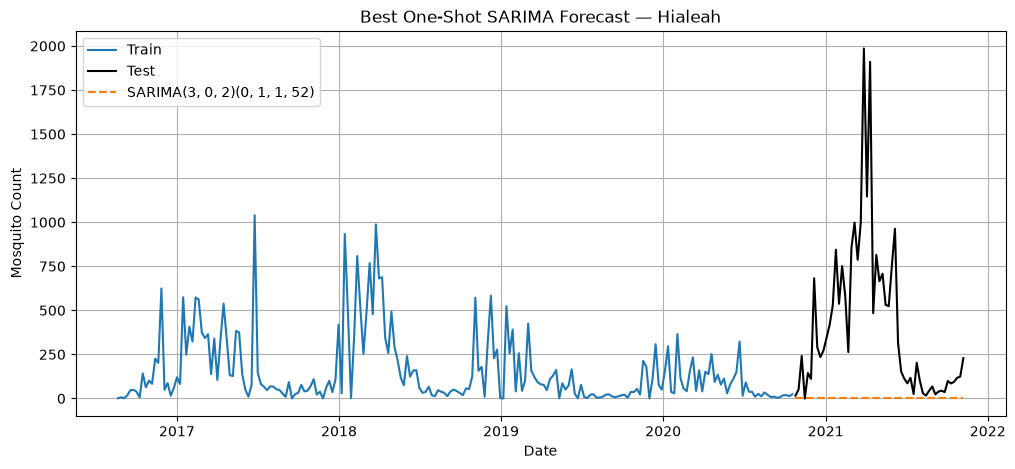

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    linestyle="--"
)

plt.title("Best One-Shot SARIMA Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

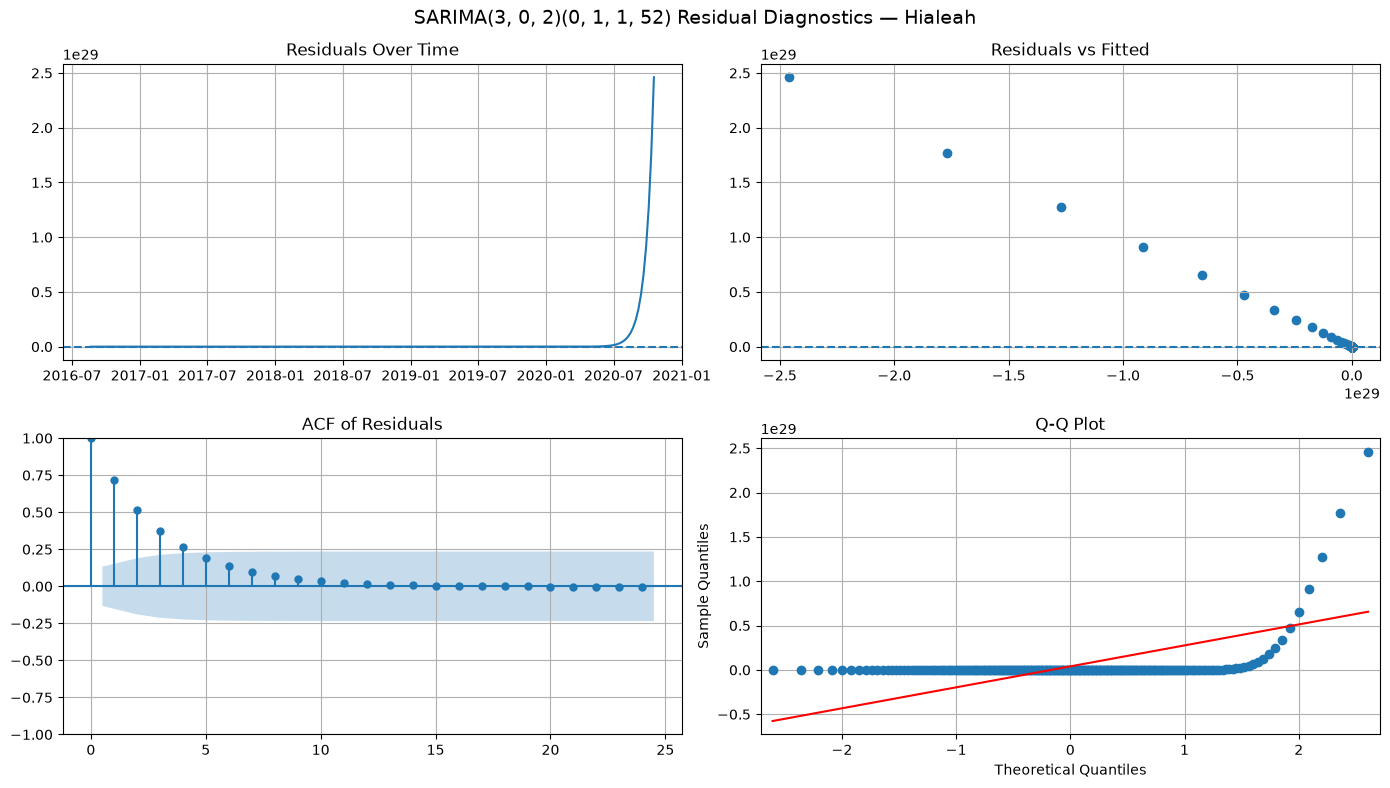

Ljung-Box Test:


,lb_stat,lb_pvalue
10,236.563014,3.607950e-45
20,236.835704,5.090739e-39


,lb_stat,lb_pvalue
10,236.563014,3.607950e-45
20,236.835704,5.090739e-39
30,236.859963,5.112796e-34


In [32]:
residual_diagnostics(
    best_sarima.resid,
    fitted_values=best_sarima.fittedvalues,
    title=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_sarima.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [33]:
def fast_rolling_sarima_forecast(
    ts,
    order,
    seasonal_order,
    initial_train_size,
    refit_every=8,
    maxiter=25
):
    
    y_true, y_pred = [], []
    pred_index = []
    
    start_time = time.time()
    
    i = initial_train_size
    
    while i < len(ts):
        train = ts.iloc[:i]
        
        steps = min(refit_every, len(ts) - i)
        test_block = ts.iloc[i:i + steps]
        
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
                simple_differencing=True
            )
            
            fitted = model.fit(
                disp=False,
                maxiter=maxiter,
                method="powell"
            )
            
            forecast = fitted.forecast(steps=steps)
            forecast = np.maximum(forecast.values, 0)
        
        except Exception:
            forecast = np.repeat(train.iloc[-1], steps)
        
        y_true.extend(test_block.values)
        y_pred.extend(forecast)
        pred_index.extend(test_block.index)
        
        print(f"Completed forecasts through index {i + steps} / {len(ts)}")
        
        i += steps
    
    elapsed = time.time() - start_time
    print(f"\nFast rolling SARIMA completed in {elapsed/60:.2f} minutes")
    
    return (
        np.array(y_true),
        np.array(y_pred),
        pd.Index(pred_index)
    )

In [34]:
fast_sarima_order = best_sarima_order
fast_sarima_seasonal_order = best_sarima_seasonal_order

y_true_roll_sarima, y_pred_roll_sarima, roll_sarima_index = fast_rolling_sarima_forecast(
    ts_series,
    order=fast_sarima_order,
    seasonal_order=fast_sarima_seasonal_order,
    initial_train_size=INITIAL_TRAIN_SIZE,
    refit_every=8,
    maxiter=25
)

rolling_sarima_metrics = compute_metrics(
    y_true_roll_sarima,
    y_pred_roll_sarima
)

print(rolling_sarima_metrics)

add_result(
    f"Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order}",
    y_true_roll_sarima,
    y_pred_roll_sarima
)

Completed forecasts through index 60 / 273
Completed forecasts through index 68 / 273
Completed forecasts through index 76 / 273


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Completed forecasts through index 84 / 273
Completed forecasts through index 92 / 273
Completed forecasts through index 100 / 273
Completed forecasts through index 108 / 273
Completed forecasts through index 116 / 273
Completed forecasts through index 124 / 273
Completed forecasts through index 132 / 273
Completed forecasts through index 140 / 273
Completed forecasts through index 148 / 273
Completed forecasts through index 156 / 273
Completed forecasts through index 164 / 273
Completed forecasts through index 172 / 273
Completed forecasts through index 180 / 273
Completed forecasts through index 188 / 273
Completed forecasts through index 196 / 273
Completed forecasts through index 204 / 273
Completed forecasts through index 212 / 273
Completed forecasts through index 220 / 273
Completed forecasts through index 228 / 273
Completed forecasts through index 236 / 273
Completed forecasts through index 244 / 273
Completed forecasts through index 252 / 273
Completed forecasts through index 

{'RMSE': np.float64(7.81789916312686e+117),
 'MAE': 5.4114551372606244e+116,
 'R2': -6.980461604306617e+230,
 'nRMSE': np.float64(3.7937633723838127e+115),
 'MAPE': np.float64(5.884899388554434e+115),
 'SMAPE': np.float64(163.10294425314908)}

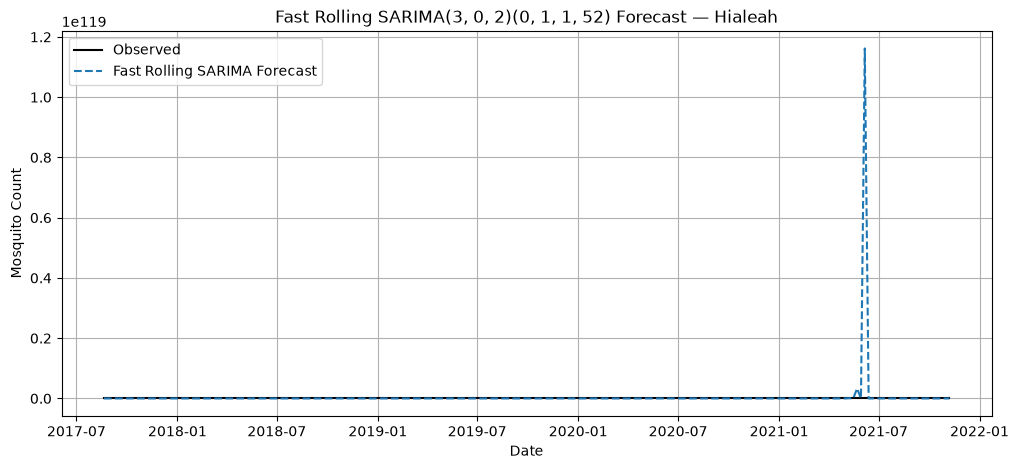

In [35]:
rolling_sarima_true = pd.Series(
    y_true_roll_sarima,
    index=roll_sarima_index,
    name="Observed"
)

rolling_sarima_pred = pd.Series(
    y_pred_roll_sarima,
    index=roll_sarima_index,
    name="Fast Rolling SARIMA Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_sarima_true.index,
    rolling_sarima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_sarima_pred.index,
    rolling_sarima_pred,
    label="Fast Rolling SARIMA Forecast",
    linestyle="--"
)

plt.title(f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Forecast — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

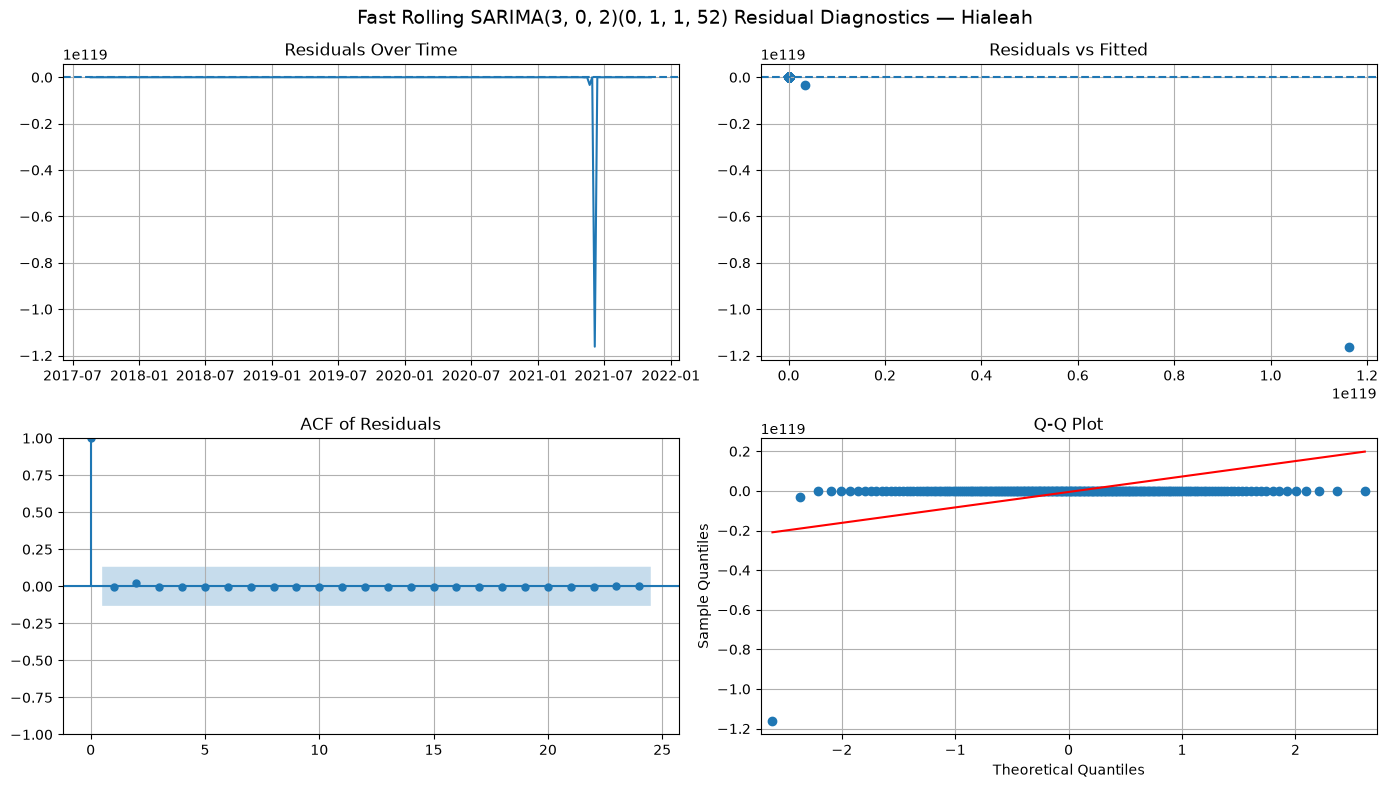

Ljung-Box Test:


,lb_stat,lb_pvalue
10,0.176907,1.0
20,0.240605,1.0


,lb_stat,lb_pvalue
10,0.176907,1.0
20,0.240605,1.0
30,0.255157,1.0


In [36]:
rolling_sarima_residuals = rolling_sarima_true - rolling_sarima_pred

residual_diagnostics(
    rolling_sarima_residuals,
    fitted_values=rolling_sarima_pred,
    title=f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        rolling_sarima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

## ETS

In [37]:
ets_results = []
ets_fits = {}
ets_forecasts = {}

ets_configs = [
    {"trend": None, "seasonal": None, "damped_trend": False, "name": "ETS Simple"},
    {"trend": "add", "seasonal": None, "damped_trend": False, "name": "ETS Additive Trend"},
    {"trend": "add", "seasonal": None, "damped_trend": True, "name": "ETS Damped Trend"},
    {"trend": None, "seasonal": "add", "damped_trend": False, "name": "ETS Additive Seasonality"},
    {"trend": "add", "seasonal": "add", "damped_trend": False, "name": "ETS Add Trend + Add Season"},
    {"trend": "add", "seasonal": "add", "damped_trend": True, "name": "ETS Damped Trend + Add Season"},
]

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)

        forecast = fitted.forecast(len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        ets_results.append({
            "Model": config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        ets_fits[config["name"]] = fitted
        ets_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

ets_results_df = pd.DataFrame(ets_results).sort_values("RMSE").reset_index(drop=True)
ets_results_df

ETS Simple {'RMSE': np.float64(587.8677703582986), 'MAE': 393.8487980776506, 'R2': -0.8086659826823039, 'nRMSE': np.float64(1.431158258220008), 'MAPE': np.float64(82.70231631480756), 'SMAPE': np.float64(151.76805166828532)}
ETS Additive Trend {'RMSE': np.float64(586.3704010898921), 'MAE': 391.3515862969006, 'R2': -0.7994639413745284, 'nRMSE': np.float64(1.42751292758251), 'MAPE': np.float64(80.4041868412763), 'SMAPE': np.float64(146.40197071349863)}
ETS Damped Trend {'RMSE': np.float64(587.8372563095722), 'MAE': 393.8081382393394, 'R2': -0.808478225188662, 'nRMSE': np.float64(1.431083972070931), 'MAPE': np.float64(82.67677803537721), 'SMAPE': np.float64(151.6946781188279)}
ETS Additive Seasonality {'RMSE': np.float64(470.35027691245483), 'MAE': 300.0571127806399, 'R2': -0.15782221204158953, 'nRMSE': np.float64(1.1450630856137136), 'MAPE': np.float64(74.97353355310192), 'SMAPE': np.float64(106.82852018188889)}
ETS Add Trend + Add Season {'RMSE': np.float64(471.22292103330216), 'MAE': 30

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Damped Trend + Add Season,add,add,True,465.413418,296.458960,-0.133644,1.133044,75.538036,107.229271,2235.977193,2428.893412
1,ETS Additive Seasonality,NaN,add,False,470.350277,300.057113,-0.157822,1.145063,74.973534,106.828520,2229.921541,2412.684274
2,ETS Add Trend + Add Season,add,add,False,471.222921,301.483318,-0.162122,1.147188,76.888573,111.570455,2233.921977,2423.453700
3,ETS Additive Trend,add,NaN,False,586.370401,391.351586,-0.799464,1.427513,80.404187,146.401971,2227.872887,2241.410867
4,ETS Damped Trend,add,NaN,True,587.837256,393.808138,-0.808478,1.431084,82.676778,151.694678,2228.604185,2245.526661
5,ETS Simple,NaN,NaN,False,587.867770,393.848798,-0.808666,1.431158,82.702316,151.768052,2223.773302,2230.542292


In [38]:
ets_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Damped Trend + Add Season,add,add,True,465.41,296.46,-0.134,1.133,75.54,107.23,2235.98,2428.89
1,ETS Additive Seasonality,nan,add,False,470.35,300.06,-0.158,1.145,74.97,106.83,2229.92,2412.68
2,ETS Add Trend + Add Season,add,add,False,471.22,301.48,-0.162,1.147,76.89,111.57,2233.92,2423.45
3,ETS Additive Trend,add,nan,False,586.37,391.35,-0.799,1.428,80.40,146.40,2227.87,2241.41
4,ETS Damped Trend,add,nan,True,587.84,393.81,-0.808,1.431,82.68,151.69,2228.60,2245.53
5,ETS Simple,nan,nan,False,587.87,393.85,-0.809,1.431,82.70,151.77,2223.77,2230.54


In [39]:
best_ets_name = ets_results_df.iloc[0]["Model"]
best_ets_model = ets_fits[best_ets_name]
best_ets_forecast = ets_forecasts[best_ets_name]

print("Best ETS model:", best_ets_name)
display(ets_results_df.iloc[[0]])

Best ETS model: ETS Damped Trend + Add Season


,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Damped Trend + Add Season,add,add,True,465.413418,296.45896,-0.133644,1.133044,75.538036,107.229271,2235.977193,2428.893412


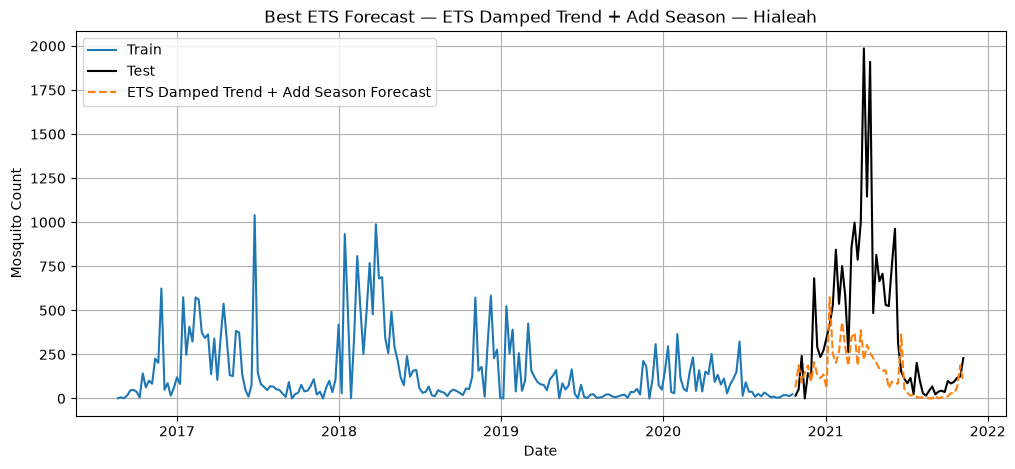

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_ets_forecast.index,
    best_ets_forecast,
    label=f"{best_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best ETS Forecast — {best_ets_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

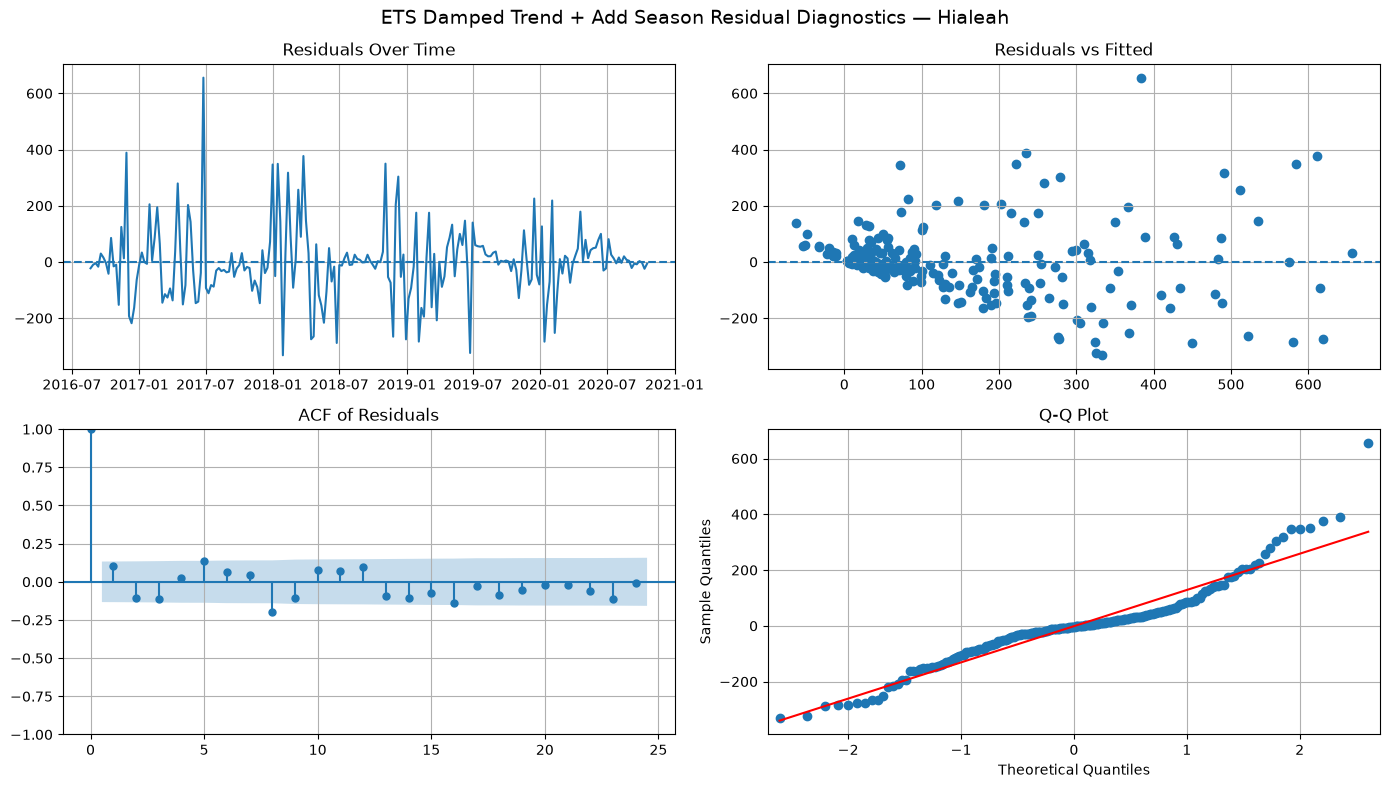

Ljung-Box Test:


,lb_stat,lb_pvalue
10,26.318105,0.003335
20,43.070706,0.002001


,lb_stat,lb_pvalue
10,26.318105,0.003335
20,43.070706,0.002001
30,62.687824,0.000430


In [41]:
residual_diagnostics(
    best_ets_model.resid,
    fitted_values=best_ets_model.fittedvalues,
    title=f"{best_ets_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [42]:
log_train_series = np.log1p(train_series)

log_ets_results = []
log_ets_fits = {}
log_ets_forecasts = {}

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            log_train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)

        log_forecast = fitted.forecast(len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        log_ets_results.append({
            "Model": "Log-" + config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_ets_fits["Log-" + config["name"]] = fitted
        log_ets_forecasts["Log-" + config["name"]] = forecast_original

        print("Log-" + config["name"], metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_ets_results_df = pd.DataFrame(log_ets_results).sort_values("RMSE").reset_index(drop=True)
log_ets_results_df

Log-ETS Simple {'RMSE': np.float64(589.298772921094), 'MAE': 395.7858175771636, 'R2': -0.817482100608429, 'nRMSE': np.float64(1.434642019770723), 'MAPE': np.float64(84.10927935905332), 'SMAPE': np.float64(155.48350296928405)}
Log-ETS Additive Trend {'RMSE': np.float64(588.2759571227231), 'MAE': 394.0406333610093, 'R2': -0.811178553921043, 'nRMSE': np.float64(1.432151984850822), 'MAPE': np.float64(82.3554495096921), 'SMAPE': np.float64(151.36105274479166)}
Log-ETS Damped Trend {'RMSE': np.float64(591.2084262754385), 'MAE': 398.53156345226427, 'R2': -0.829280477052265, 'nRMSE': np.float64(1.4392910519276343), 'MAPE': np.float64(87.04104300946612), 'SMAPE': np.float64(161.8687616305973)}
Log-ETS Additive Seasonality {'RMSE': np.float64(525.2648287365624), 'MAE': 339.71893903105, 'R2': -0.4439618277664361, 'nRMSE': np.float64(1.2787520175509444), 'MAPE': np.float64(75.7888565511654), 'SMAPE': np.float64(121.80526813368309)}
Log-ETS Add Trend + Add Season {'RMSE': np.float64(528.22105311652

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-ETS Additive Seasonality,NaN,add,False,525.264829,339.718939,-0.443962,1.278752,75.788857,121.805268,129.502971,312.265704
1,Log-ETS Add Trend + Add Season,add,add,False,528.221053,342.800692,-0.460261,1.285949,76.923765,124.637587,133.461712,322.993435
2,Log-ETS Damped Trend + Add Season,add,add,True,531.783097,345.921753,-0.480022,1.294621,75.670967,124.167079,126.280195,319.196414
3,Log-ETS Additive Trend,add,NaN,False,588.275957,394.040633,-0.811179,1.432152,82.355450,151.361053,112.192993,125.730973
4,Log-ETS Simple,NaN,NaN,False,589.298773,395.785818,-0.817482,1.434642,84.109279,155.483503,108.213986,114.982976
5,Log-ETS Damped Trend,add,NaN,True,591.208426,398.531563,-0.829280,1.439291,87.041043,161.868762,104.044364,120.966839


In [43]:
all_ets_results_df = pd.concat(
    [ets_results_df, log_ets_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_ets_results_df

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Damped Trend + Add Season,add,add,True,465.413418,296.458960,-0.133644,1.133044,75.538036,107.229271,2235.977193,2428.893412
1,ETS Additive Seasonality,NaN,add,False,470.350277,300.057113,-0.157822,1.145063,74.973534,106.828520,2229.921541,2412.684274
2,ETS Add Trend + Add Season,add,add,False,471.222921,301.483318,-0.162122,1.147188,76.888573,111.570455,2233.921977,2423.453700
3,Log-ETS Additive Seasonality,NaN,add,False,525.264829,339.718939,-0.443962,1.278752,75.788857,121.805268,129.502971,312.265704
4,Log-ETS Add Trend + Add Season,add,add,False,528.221053,342.800692,-0.460261,1.285949,76.923765,124.637587,133.461712,322.993435
5,Log-ETS Damped Trend + Add Season,add,add,True,531.783097,345.921753,-0.480022,1.294621,75.670967,124.167079,126.280195,319.196414
6,ETS Additive Trend,add,NaN,False,586.370401,391.351586,-0.799464,1.427513,80.404187,146.401971,2227.872887,2241.410867
7,ETS Damped Trend,add,NaN,True,587.837256,393.808138,-0.808478,1.431084,82.676778,151.694678,2228.604185,2245.526661
8,ETS Simple,NaN,NaN,False,587.867770,393.848798,-0.808666,1.431158,82.702316,151.768052,2223.773302,2230.542292
9,Log-ETS Additive Trend,add,NaN,False,588.275957,394.040633,-0.811179,1.432152,82.355450,151.361053,112.192993,125.730973


In [44]:
best_overall_ets_name = all_ets_results_df.iloc[0]["Model"]

if best_overall_ets_name.startswith("Log-"):
    best_overall_ets_model = log_ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = log_ets_forecasts[best_overall_ets_name]
else:
    best_overall_ets_model = ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = ets_forecasts[best_overall_ets_name]

print("Best overall ETS model:", best_overall_ets_name)
display(all_ets_results_df.iloc[[0]])

Best overall ETS model: ETS Damped Trend + Add Season


,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Damped Trend + Add Season,add,add,True,465.413418,296.45896,-0.133644,1.133044,75.538036,107.229271,2235.977193,2428.893412


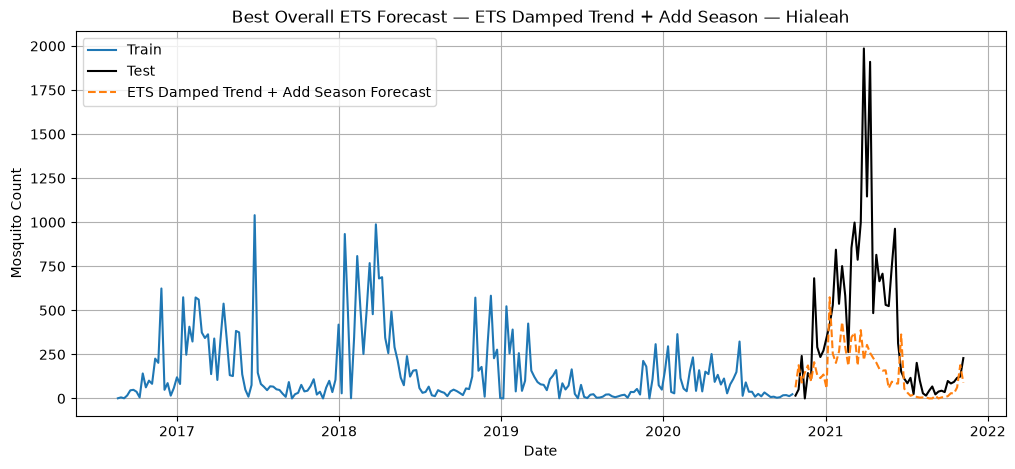

In [45]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_overall_ets_forecast.index,
    best_overall_ets_forecast,
    label=f"{best_overall_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall ETS Forecast — {best_overall_ets_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

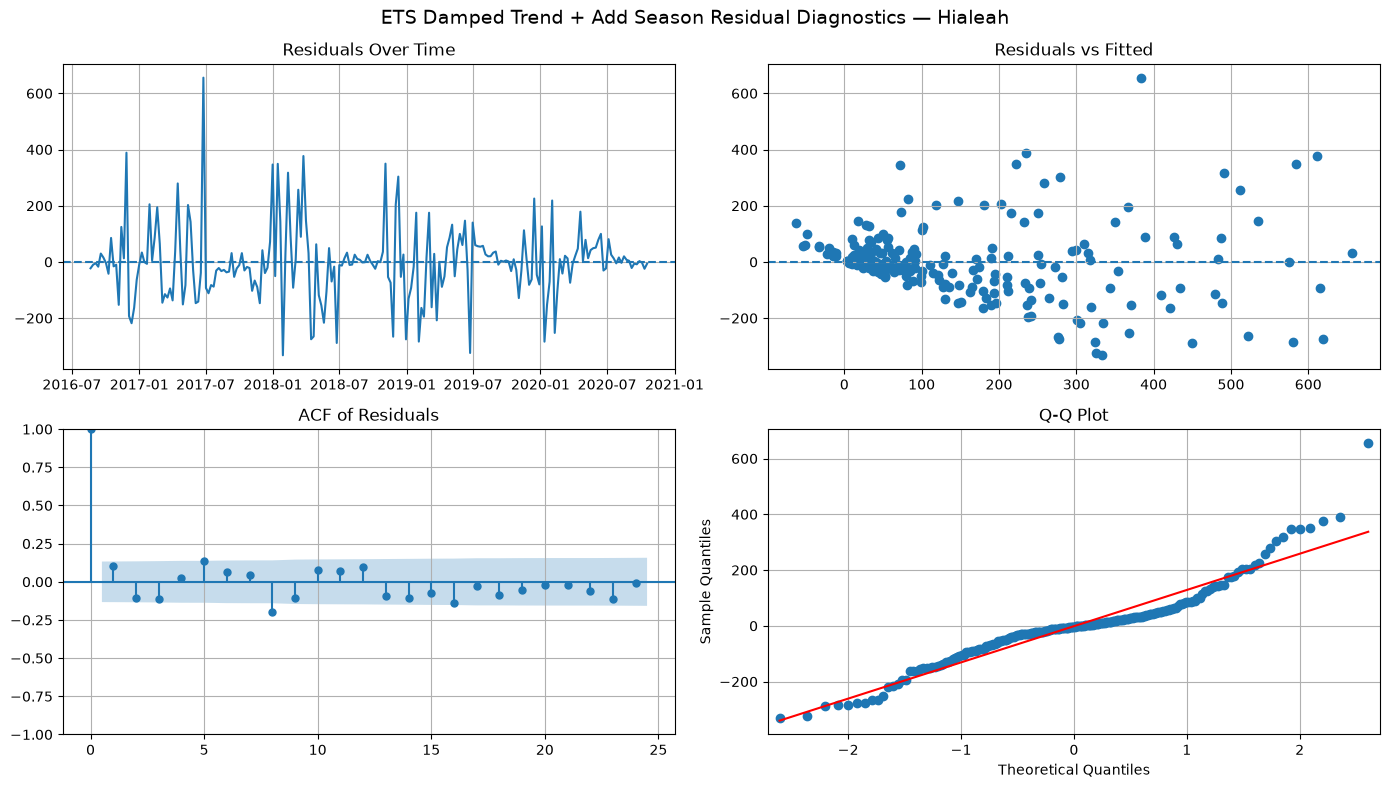

Ljung-Box Test:


,lb_stat,lb_pvalue
10,26.318105,0.003335
20,43.070706,0.002001


,lb_stat,lb_pvalue
10,26.318105,0.003335
20,43.070706,0.002001
30,62.687824,0.000430


In [46]:
residual_diagnostics(
    best_overall_ets_model.resid,
    fitted_values=best_overall_ets_model.fittedvalues,
    title=f"{best_overall_ets_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_overall_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [47]:
add_result(
    best_overall_ets_name,
    test_series,
    best_overall_ets_forecast
)

{'RMSE': np.float64(465.4134181905896),
 'MAE': 296.45896048731584,
 'R2': -0.13364445774077716,
 'nRMSE': np.float64(1.1330443520043567),
 'MAPE': np.float64(75.53803608245433),
 'SMAPE': np.float64(107.22927113398654)}

## Structural State Space Model

In [48]:
structural_results = []
structural_fits = {}
structural_forecasts = {}

structural_configs = [
    {"level": "local level", "seasonal": None, "name": "Local Level"},
    {"level": "local linear trend", "seasonal": None, "name": "Local Linear Trend"},
    {"level": "local level", "seasonal": 52, "name": "Local Level + Seasonal"},
    {"level": "local linear trend", "seasonal": 52, "name": "Local Linear Trend + Seasonal"},
]

for config in structural_configs:
    try:
        model = UnobservedComponents(
            train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        structural_results.append({
            "Model": config["name"],
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        structural_fits[config["name"]] = fitted
        structural_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

structural_results_df = pd.DataFrame(structural_results).sort_values("RMSE").reset_index(drop=True)
structural_results_df

Local Level {'RMSE': np.float64(587.8762242509385), 'MAE': 393.86006177195657, 'R2': -0.8087180024689011, 'nRMSE': np.float64(1.4311788391378197), 'MAPE': np.float64(82.70938885753422), 'SMAPE': np.float64(151.78838641347662)}
Local Linear Trend {'RMSE': np.float64(587.9762600327832), 'MAE': 394.0219100912858, 'R2': -0.8093336147578607, 'nRMSE': np.float64(1.4314223752568642), 'MAPE': np.float64(82.85324634467703), 'SMAPE': np.float64(152.14594493278943)}
Local Level + Seasonal {'RMSE': np.float64(474.6276888890141), 'MAE': 303.7544513366505, 'R2': -0.17897666660107858, 'nRMSE': np.float64(1.1554764026600468), 'MAPE': np.float64(75.23551902783396), 'SMAPE': np.float64(108.08012710546635)}
Local Linear Trend + Seasonal {'RMSE': np.float64(476.016828474652), 'MAE': 305.68840128952485, 'R2': -0.18588802005918414, 'nRMSE': np.float64(1.1588582492079436), 'MAPE': np.float64(77.36579838375803), 'SMAPE': np.float64(113.50846600831972)}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Level + Seasonal,local level,52.0,474.627689,303.754451,-0.178977,1.155476,75.235519,108.080127,2210.322663,2219.658626
1,Local Linear Trend + Seasonal,local linear trend,52.0,476.016828,305.688401,-0.185888,1.158858,77.365798,113.508466,2200.873004,2213.296786
2,Local Level,local level,NaN,587.876224,393.860062,-0.808718,1.431179,82.709389,151.788386,2831.095514,2837.855309
3,Local Linear Trend,local linear trend,NaN,587.976260,394.021910,-0.809334,1.431422,82.853246,152.145945,2828.828273,2838.954109


In [49]:
log_structural_results = []
log_structural_fits = {}
log_structural_forecasts = {}

log_train_series = np.log1p(train_series)

for config in structural_configs:
    try:
        model = UnobservedComponents(
            log_train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        log_forecast = fitted.forecast(steps=len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        model_name = "Log-" + config["name"]

        log_structural_results.append({
            "Model": model_name,
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_structural_fits[model_name] = fitted
        log_structural_forecasts[model_name] = forecast_original

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_structural_results_df = pd.DataFrame(log_structural_results).sort_values("RMSE").reset_index(drop=True)
log_structural_results_df

Log-Local Level {'RMSE': np.float64(589.2886740358834), 'MAE': 395.7713069189333, 'R2': -0.8174198083156985, 'nRMSE': np.float64(1.4346174341348084), 'MAPE': np.float64(84.09388427252344), 'SMAPE': np.float64(155.45127767647463)}
Log-Local Linear Trend {'RMSE': np.float64(597.9673576055937), 'MAE': 408.44310242134867, 'R2': -0.8713456965772324, 'nRMSE': np.float64(1.4557456032359977), 'MAPE': np.float64(97.79396985416476), 'SMAPE': np.float64(193.24780651046567)}
Log-Local Level + Seasonal {'RMSE': np.float64(524.4394476952466), 'MAE': 338.9407256819136, 'R2': -0.4394274205009199, 'nRMSE': np.float64(1.2767426355895257), 'MAPE': np.float64(75.65184935409334), 'SMAPE': np.float64(121.30709347117855)}
Log-Local Linear Trend + Seasonal {'RMSE': np.float64(528.6850808273609), 'MAE': 343.18853407103524, 'R2': -0.46282771163858283, 'nRMSE': np.float64(1.2870785873541453), 'MAPE': np.float64(76.89040128543799), 'SMAPE': np.float64(124.75558049900883)}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Level + Seasonal,local level,52.0,524.439448,338.940726,-0.439427,1.276743,75.651849,121.307093,612.318899,621.654863
1,Log-Local Linear Trend + Seasonal,local linear trend,52.0,528.685081,343.188534,-0.462828,1.287079,76.890401,124.755580,614.276122,626.699904
2,Log-Local Level,local level,NaN,589.288674,395.771307,-0.817420,1.434617,84.093884,155.451278,725.316947,732.076742
3,Log-Local Linear Trend,local linear trend,NaN,597.967358,408.443102,-0.871346,1.455746,97.793970,193.247807,734.985464,745.111299


In [50]:
all_structural_results_df = pd.concat(
    [structural_results_df, log_structural_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_structural_results_df

,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Level + Seasonal,local level,52.0,474.627689,303.754451,-0.178977,1.155476,75.235519,108.080127,2210.322663,2219.658626
1,Local Linear Trend + Seasonal,local linear trend,52.0,476.016828,305.688401,-0.185888,1.158858,77.365798,113.508466,2200.873004,2213.296786
2,Log-Local Level + Seasonal,local level,52.0,524.439448,338.940726,-0.439427,1.276743,75.651849,121.307093,612.318899,621.654863
3,Log-Local Linear Trend + Seasonal,local linear trend,52.0,528.685081,343.188534,-0.462828,1.287079,76.890401,124.755580,614.276122,626.699904
4,Local Level,local level,NaN,587.876224,393.860062,-0.808718,1.431179,82.709389,151.788386,2831.095514,2837.855309
5,Local Linear Trend,local linear trend,NaN,587.976260,394.021910,-0.809334,1.431422,82.853246,152.145945,2828.828273,2838.954109
6,Log-Local Level,local level,NaN,589.288674,395.771307,-0.817420,1.434617,84.093884,155.451278,725.316947,732.076742
7,Log-Local Linear Trend,local linear trend,NaN,597.967358,408.443102,-0.871346,1.455746,97.793970,193.247807,734.985464,745.111299


In [51]:
best_structural_name = all_structural_results_df.iloc[0]["Model"]

if best_structural_name.startswith("Log-"):
    best_structural_model = log_structural_fits[best_structural_name]
    best_structural_forecast = log_structural_forecasts[best_structural_name]
else:
    best_structural_model = structural_fits[best_structural_name]
    best_structural_forecast = structural_forecasts[best_structural_name]

print("Best Structural Model:", best_structural_name)
display(all_structural_results_df.iloc[[0]])

Best Structural Model: Local Level + Seasonal


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Level + Seasonal,local level,52.0,474.627689,303.754451,-0.178977,1.155476,75.235519,108.080127,2210.322663,2219.658626


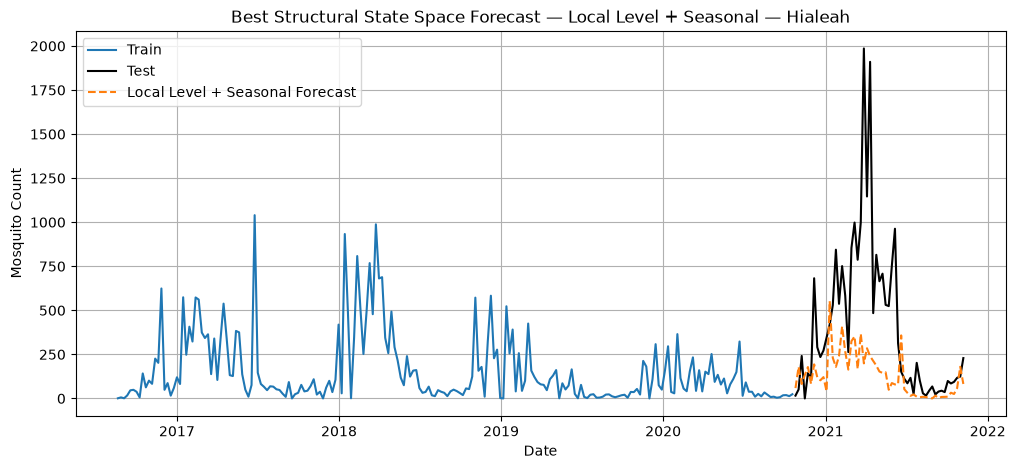

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_structural_forecast.index,
    best_structural_forecast,
    label=f"{best_structural_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Structural State Space Forecast — {best_structural_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

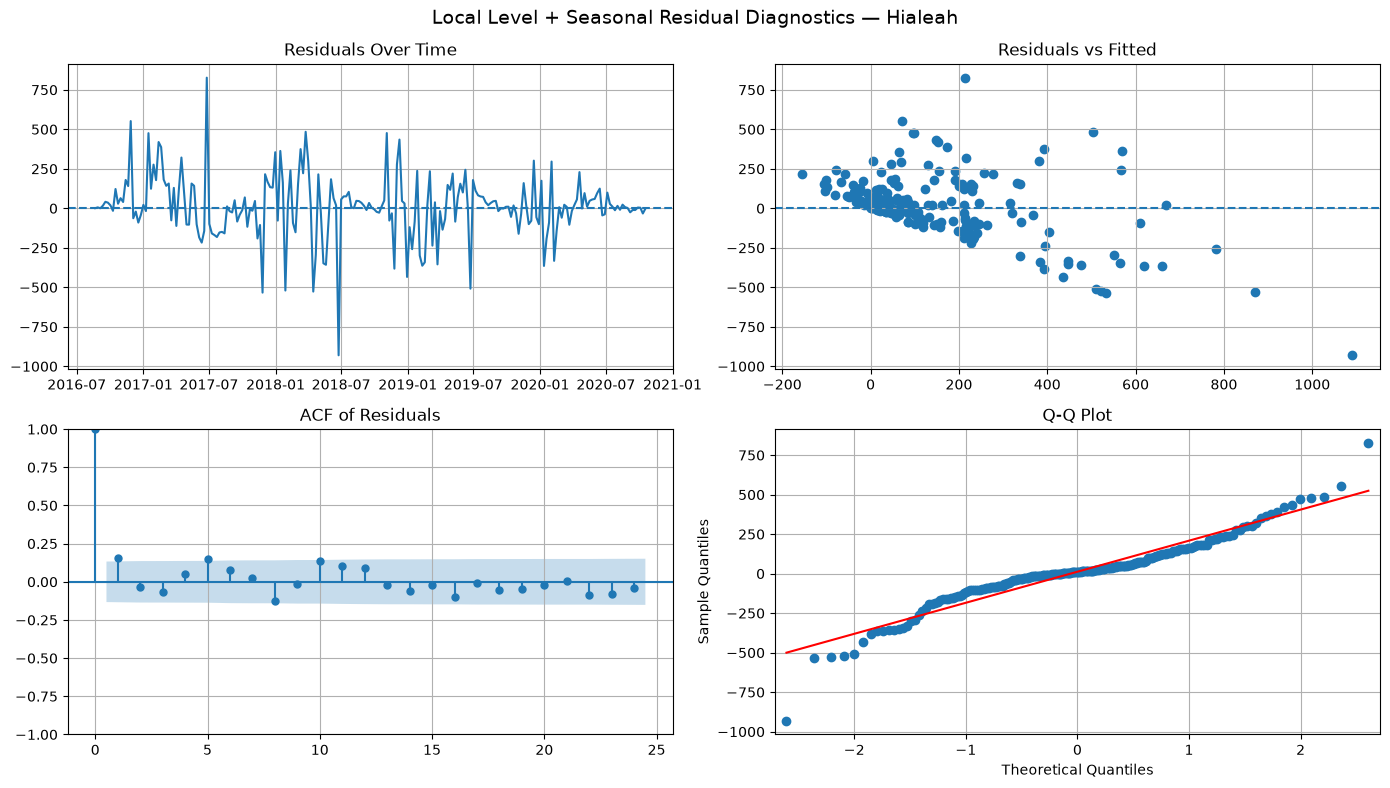

Ljung-Box Test:


,lb_stat,lb_pvalue
10,21.639606,0.017050
20,30.735878,0.058775


,lb_stat,lb_pvalue
10,21.639606,0.017050
20,30.735878,0.058775
30,47.557276,0.021937


{'RMSE': np.float64(474.6276888890141),
 'MAE': 303.7544513366505,
 'R2': -0.17897666660107858,
 'nRMSE': np.float64(1.1554764026600468),
 'MAPE': np.float64(75.23551902783396),
 'SMAPE': np.float64(108.08012710546635)}

In [53]:
residual_diagnostics(
    best_structural_model.resid,
    fitted_values=best_structural_model.fittedvalues,
    title=f"{best_structural_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(best_structural_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

add_result(
    best_structural_name,
    test_series,
    best_structural_forecast
)

## Prophet

In [54]:
def prepare_prophet_df(ts):
    df = ts.reset_index()
    df.columns = ["ds", "y"]
    return df

prophet_df = prepare_prophet_df(ts_series)

train_prophet = prophet_df.iloc[:train_size].copy()
test_prophet = prophet_df.iloc[train_size:].copy()

train_prophet.head()

,ds,y
0,2016-08-21,1
1,2016-08-28,6
2,2016-09-04,1
3,2016-09-11,17
4,2016-09-18,46


In [55]:
# ============================================================
# 42. Prophet Hyperparameter Variations
# ============================================================

prophet_configs = [
    {
        "name": "Prophet Default",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Flexible Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.5,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Conservative Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.01,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Multiplicative Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "multiplicative",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Strong Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 20.0
    },
]

In [56]:
prophet_results = []
prophet_models = {}
prophet_forecasts = {}

for config in prophet_configs:
    try:
        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast = np.maximum(test_forecast, 0)

        metrics = compute_metrics(test_series.values, test_forecast)

        prophet_results.append({
            "Model": config["name"],
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        prophet_models[config["name"]] = model
        prophet_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

prophet_results_df = pd.DataFrame(prophet_results).sort_values("RMSE").reset_index(drop=True)
prophet_results_df

02:31:46 - cmdstanpy - INFO - Chain [1] start processing
02:31:47 - cmdstanpy - INFO - Chain [1] done processing
02:31:47 - cmdstanpy - INFO - Chain [1] start processing
02:31:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet Default {'RMSE': np.float64(509.4103146467173), 'MAE': 334.6407471791358, 'R2': -0.3581087199225792, 'nRMSE': np.float64(1.2401543601969482), 'MAPE': np.float64(79.59756082982523), 'SMAPE': np.float64(145.0752472113955)}
Prophet Flexible Trend {'RMSE': np.float64(474.166824338575), 'MAE': 297.8834905799941, 'R2': -0.17668820021863252, 'nRMSE': np.float64(1.1543544324814814), 'MAPE': np.float64(67.68154233198284), 'SMAPE': np.float64(106.61042346760622)}


02:31:47 - cmdstanpy - INFO - Chain [1] start processing
02:31:47 - cmdstanpy - INFO - Chain [1] done processing
02:31:47 - cmdstanpy - INFO - Chain [1] start processing
02:31:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet Conservative Trend {'RMSE': np.float64(494.98346303383204), 'MAE': 319.82346735397823, 'R2': -0.28227285448236183, 'nRMSE': np.float64(1.205032332987817), 'MAPE': np.float64(76.80914669363396), 'SMAPE': np.float64(134.97097113773785)}
Prophet Multiplicative Seasonality {'RMSE': np.float64(583.7138126050689), 'MAE': 395.8115812822553, 'R2': -0.7831957049715386, 'nRMSE': np.float64(1.4210454892563205), 'MAPE': np.float64(94.36013757519187), 'SMAPE': np.float64(181.7902531887914)}


02:31:48 - cmdstanpy - INFO - Chain [1] start processing
02:31:48 - cmdstanpy - INFO - Chain [1] done processing


Prophet Strong Seasonality {'RMSE': np.float64(509.7771370209114), 'MAE': 335.03764263117336, 'R2': -0.3600653510317755, 'nRMSE': np.float64(1.2410473856298747), 'MAPE': np.float64(79.81344214834891), 'SMAPE': np.float64(145.4437138299039)}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.50,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423
1,Prophet Conservative Trend,additive,0.01,10.0,494.983463,319.823467,-0.282273,1.205032,76.809147,134.970971
2,Prophet Default,additive,0.05,10.0,509.410315,334.640747,-0.358109,1.240154,79.597561,145.075247
3,Prophet Strong Seasonality,additive,0.05,20.0,509.777137,335.037643,-0.360065,1.241047,79.813442,145.443714
4,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,583.713813,395.811581,-0.783196,1.421045,94.360138,181.790253


Best Prophet model: Prophet Flexible Trend


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.5,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423


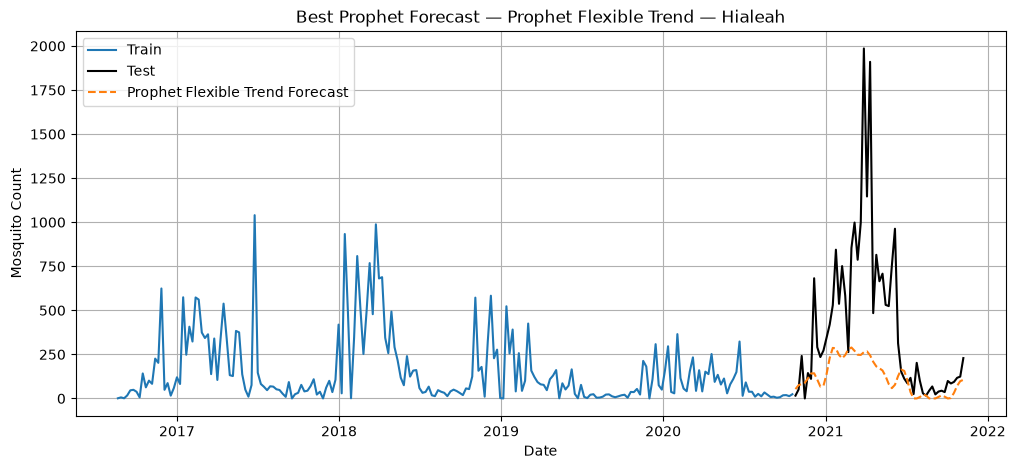

In [57]:
best_prophet_name = prophet_results_df.iloc[0]["Model"]
best_prophet_model = prophet_models[best_prophet_name]
best_prophet_forecast = prophet_forecasts[best_prophet_name]

print("Best Prophet model:", best_prophet_name)
display(prophet_results_df.iloc[[0]])

best_prophet_test_forecast = best_prophet_forecast.iloc[train_size:]["yhat"].values
best_prophet_test_forecast = np.maximum(best_prophet_test_forecast, 0)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_prophet_test_forecast,
    label=f"{best_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Prophet Forecast — {best_prophet_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

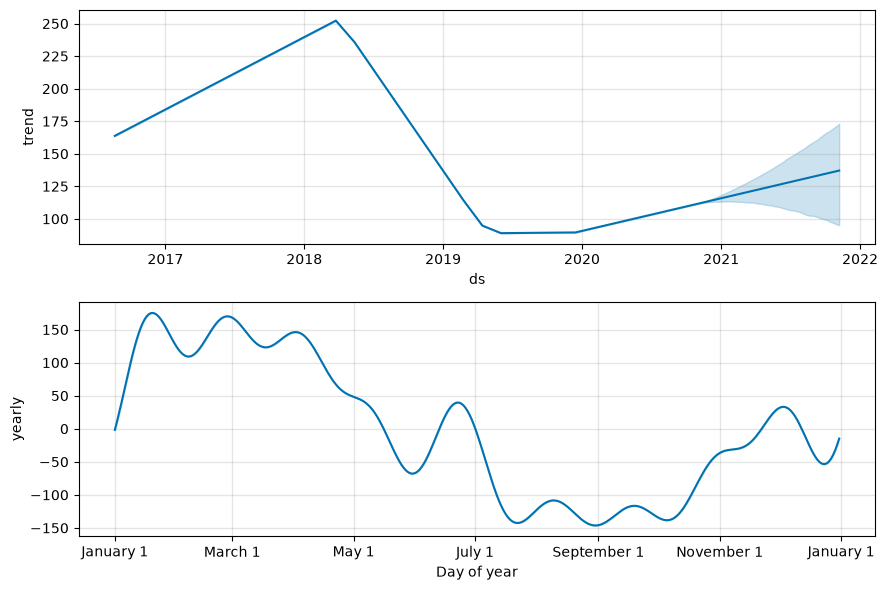

In [58]:
best_prophet_model.plot_components(best_prophet_forecast)
plt.show()

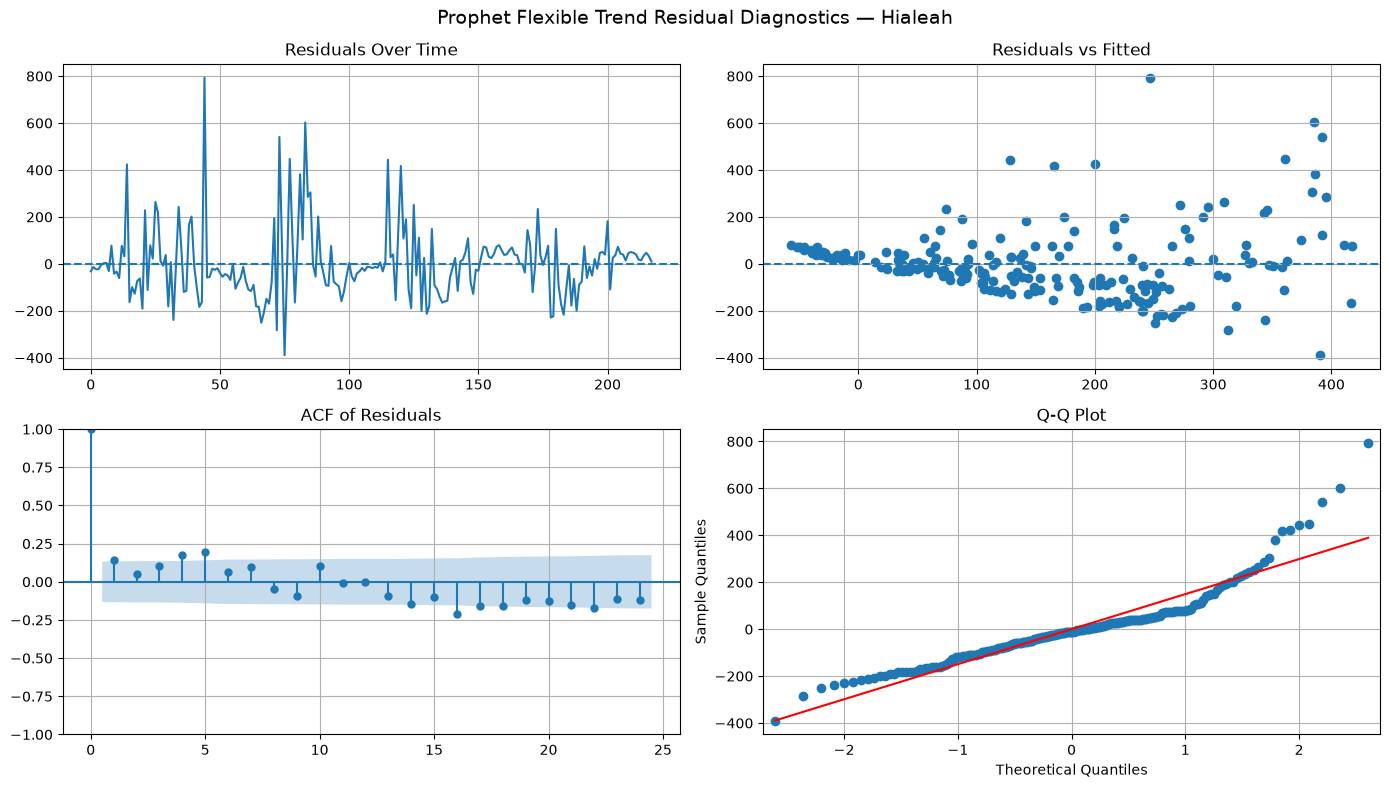

Ljung-Box Test:


,lb_stat,lb_pvalue
10,30.660900,6.673404e-04
20,69.911173,1.883206e-07


,lb_stat,lb_pvalue
10,30.660900,6.673404e-04
20,69.911173,1.883206e-07
30,101.866289,9.398467e-10


In [59]:
prophet_train_forecast = best_prophet_forecast.iloc[:train_size]

prophet_train_residuals = (
    train_prophet["y"].values - prophet_train_forecast["yhat"].values
)

residual_diagnostics(
    prophet_train_residuals,
    fitted_values=prophet_train_forecast["yhat"].values,
    title=f"{best_prophet_name} Residual Diagnostics — Hialeah"
)

display(
    acorr_ljungbox(
        pd.Series(prophet_train_residuals).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [60]:
log_prophet_df = prophet_df.copy()
log_prophet_df["y"] = np.log1p(log_prophet_df["y"])

log_train_prophet = log_prophet_df.iloc[:train_size].copy()

log_prophet_results = []
log_prophet_models = {}
log_prophet_forecasts = {}

for config in prophet_configs:
    try:
        model_name = "Log-" + config["name"]

        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(log_train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        log_test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast_original = np.expm1(log_test_forecast)
        test_forecast_original = np.maximum(test_forecast_original, 0)

        metrics = compute_metrics(test_series.values, test_forecast_original)

        log_prophet_results.append({
            "Model": model_name,
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_prophet_models[model_name] = model
        log_prophet_forecasts[model_name] = forecast

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_prophet_results_df = pd.DataFrame(log_prophet_results).sort_values("RMSE").reset_index(drop=True)
log_prophet_results_df

02:31:49 - cmdstanpy - INFO - Chain [1] start processing
02:31:49 - cmdstanpy - INFO - Chain [1] done processing
02:31:49 - cmdstanpy - INFO - Chain [1] start processing
02:31:49 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Default {'RMSE': np.float64(541.5601481858081), 'MAE': 358.45867722594363, 'R2': -0.5349437530056624, 'nRMSE': np.float64(1.3184228111818097), 'MAPE': np.float64(80.83791915555506), 'SMAPE': np.float64(136.36064211443508)}
Log-Prophet Flexible Trend {'RMSE': np.float64(507.6000417716627), 'MAE': 326.1624089737598, 'R2': -0.3484733478801656, 'nRMSE': np.float64(1.235747268831509), 'MAPE': np.float64(70.60891120259633), 'SMAPE': np.float64(107.5745159306924)}


02:31:49 - cmdstanpy - INFO - Chain [1] start processing
02:31:49 - cmdstanpy - INFO - Chain [1] done processing
02:31:49 - cmdstanpy - INFO - Chain [1] start processing
02:31:49 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Conservative Trend {'RMSE': np.float64(543.3779067384697), 'MAE': 360.34002172314393, 'R2': -0.5452651910071433, 'nRMSE': np.float64(1.3228481263551628), 'MAPE': np.float64(81.35215762575838), 'SMAPE': np.float64(138.4892598397364)}
Log-Prophet Multiplicative Seasonality {'RMSE': np.float64(551.1448937920471), 'MAE': 365.3828099215699, 'R2': -0.5897566310950773, 'nRMSE': np.float64(1.3417567793273102), 'MAPE': np.float64(80.8807012222501), 'SMAPE': np.float64(138.01226730110866)}


02:31:49 - cmdstanpy - INFO - Chain [1] start processing
02:31:49 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Strong Seasonality {'RMSE': np.float64(541.695712856471), 'MAE': 358.5987933111241, 'R2': -0.5357123109917967, 'nRMSE': np.float64(1.318752842028413), 'MAPE': np.float64(80.89200877102418), 'SMAPE': np.float64(136.54365765549448)}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-Prophet Flexible Trend,additive,0.50,10.0,507.600042,326.162409,-0.348473,1.235747,70.608911,107.574516
1,Log-Prophet Default,additive,0.05,10.0,541.560148,358.458677,-0.534944,1.318423,80.837919,136.360642
2,Log-Prophet Strong Seasonality,additive,0.05,20.0,541.695713,358.598793,-0.535712,1.318753,80.892009,136.543658
3,Log-Prophet Conservative Trend,additive,0.01,10.0,543.377907,360.340022,-0.545265,1.322848,81.352158,138.489260
4,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,551.144894,365.382810,-0.589757,1.341757,80.880701,138.012267


In [61]:
all_prophet_results_df = pd.concat(
    [prophet_results_df, log_prophet_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(all_prophet_results_df)

best_overall_prophet_name = all_prophet_results_df.iloc[0]["Model"]

if best_overall_prophet_name.startswith("Log-"):
    best_overall_prophet_model = log_prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = log_prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = True
else:
    best_overall_prophet_model = prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = False

print("Best overall Prophet model:", best_overall_prophet_name)
display(all_prophet_results_df.iloc[[0]])

,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.50,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423
1,Prophet Conservative Trend,additive,0.01,10.0,494.983463,319.823467,-0.282273,1.205032,76.809147,134.970971
2,Log-Prophet Flexible Trend,additive,0.50,10.0,507.600042,326.162409,-0.348473,1.235747,70.608911,107.574516
3,Prophet Default,additive,0.05,10.0,509.410315,334.640747,-0.358109,1.240154,79.597561,145.075247
4,Prophet Strong Seasonality,additive,0.05,20.0,509.777137,335.037643,-0.360065,1.241047,79.813442,145.443714
5,Log-Prophet Default,additive,0.05,10.0,541.560148,358.458677,-0.534944,1.318423,80.837919,136.360642
6,Log-Prophet Strong Seasonality,additive,0.05,20.0,541.695713,358.598793,-0.535712,1.318753,80.892009,136.543658
7,Log-Prophet Conservative Trend,additive,0.01,10.0,543.377907,360.340022,-0.545265,1.322848,81.352158,138.489260
8,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,551.144894,365.382810,-0.589757,1.341757,80.880701,138.012267
9,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,583.713813,395.811581,-0.783196,1.421045,94.360138,181.790253


Best overall Prophet model: Prophet Flexible Trend


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.5,10.0,474.166824,297.883491,-0.176688,1.154354,67.681542,106.610423


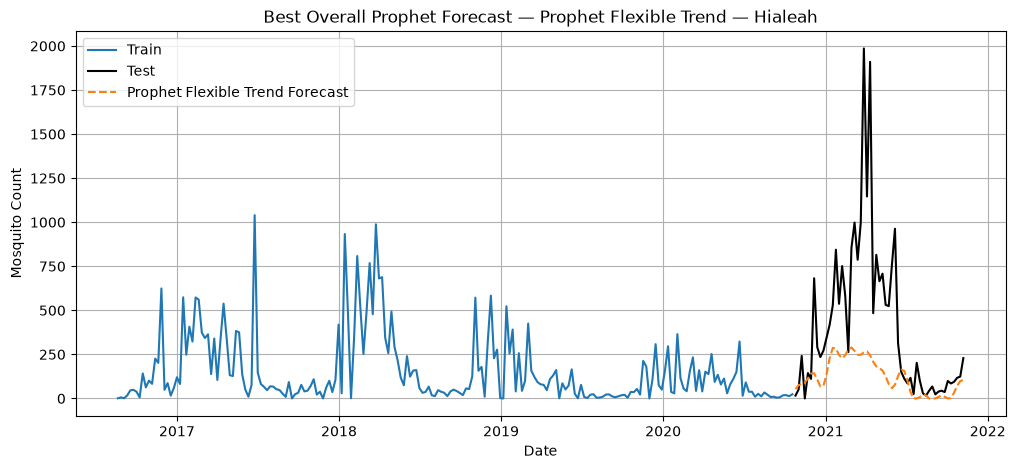

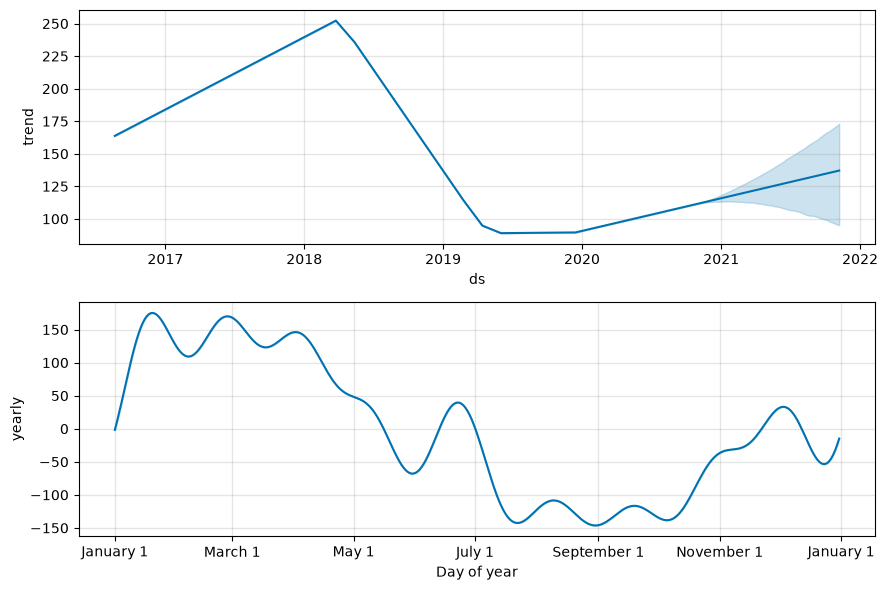

{'RMSE': np.float64(474.166824338575),
 'MAE': 297.8834905799941,
 'R2': -0.17668820021863252,
 'nRMSE': np.float64(1.1543544324814814),
 'MAPE': np.float64(67.68154233198284),
 'SMAPE': np.float64(106.61042346760622)}

In [62]:
if is_log_prophet:
    best_overall_prophet_test_forecast = np.expm1(
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )
else:
    best_overall_prophet_test_forecast = (
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )

best_overall_prophet_test_forecast = np.maximum(
    best_overall_prophet_test_forecast,
    0
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_overall_prophet_test_forecast,
    label=f"{best_overall_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall Prophet Forecast — {best_overall_prophet_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

best_overall_prophet_model.plot_components(best_overall_prophet_forecast)
plt.show()

add_result(
    best_overall_prophet_name,
    test_series.values,
    best_overall_prophet_test_forecast
)

## LSTM

In [63]:
tf.random.set_seed(42)
np.random.seed(42)

def create_lstm_sequences(data, lookback):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [64]:
def fit_evaluate_lstm(train_series, test_series, lookback=12, units=64, dropout=0.2, epochs=150):
    scaler = MinMaxScaler()

    train_values = train_series.values.reshape(-1, 1)
    test_values = test_series.values.reshape(-1, 1)

    scaled_train = scaler.fit_transform(train_values)

    combined_values = np.concatenate([train_values[-lookback:], test_values])
    scaled_combined = scaler.transform(combined_values)

    X_train, y_train = create_lstm_sequences(scaled_train, lookback)
    X_test, y_test = create_lstm_sequences(scaled_combined, lookback)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = Sequential([
        LSTM(units, activation="tanh", input_shape=(lookback, 1)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    y_pred = scaler.inverse_transform(pred_scaled).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    y_pred = np.maximum(y_pred, 0)

    metrics = compute_metrics(y_true, y_pred)

    return {
        "model": model,
        "history": history,
        "scaler": scaler,
        "lookback": lookback,
        "units": units,
        "dropout": dropout,
        "y_true": y_true,
        "y_pred": y_pred,
        "metrics": metrics
    }

In [65]:
lstm_configs = [
    {"name": "LSTM Lookback 4", "lookback": 4, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 8", "lookback": 8, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 12", "lookback": 12, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 16", "lookback": 16, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 24", "lookback": 24, "units": 64, "dropout": 0.3},
]

lstm_results = []
lstm_outputs = {}

for config in lstm_configs:
    print("Fitting:", config["name"])

    try:
        output = fit_evaluate_lstm(
            train_series=train_series,
            test_series=test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        metrics = output["metrics"]

        lstm_results.append({
            "Model": config["name"],
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        lstm_outputs[config["name"]] = output

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

lstm_results_df = pd.DataFrame(lstm_results).sort_values("RMSE").reset_index(drop=True)
lstm_results_df

Fitting: LSTM Lookback 4
LSTM Lookback 4 {'RMSE': np.float64(433.4446171308204), 'MAE': 263.8337227561257, 'R2': 0.016744698610163145, 'nRMSE': np.float64(1.055216622795464), 'MAPE': np.float64(85.33994263224292), 'SMAPE': np.float64(74.26291856352958)}
Fitting: LSTM Lookback 8
LSTM Lookback 8 {'RMSE': np.float64(325.89715711329217), 'MAE': 204.72057945945045, 'R2': 0.44414666855602614, 'nRMSE': np.float64(0.7933933977173809), 'MAPE': np.float64(95.19385207451292), 'SMAPE': np.float64(60.02327640839161)}
Fitting: LSTM Lookback 12
LSTM Lookback 12 {'RMSE': np.float64(357.9902230200829), 'MAE': 224.265703235973, 'R2': 0.32927977755486537, 'nRMSE': np.float64(0.8715236484642599), 'MAPE': np.float64(108.23251050896468), 'SMAPE': np.float64(66.91378366339508)}
Fitting: LSTM Lookback 16
LSTM Lookback 16 {'RMSE': np.float64(323.6132477103948), 'MAE': 189.1192474712025, 'R2': 0.4519102846923343, 'nRMSE': np.float64(0.7878332429210213), 'MAPE': np.float64(53.722954271822985), 'SMAPE': np.float6

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 16,16,64,0.2,323.613248,189.119247,0.451910,0.787833,53.722954,55.469551
1,LSTM Lookback 8,8,32,0.2,325.897157,204.720579,0.444147,0.793393,95.193852,60.023276
2,LSTM Lookback 12,12,64,0.2,357.990223,224.265703,0.329280,0.871524,108.232511,66.913784
3,LSTM Lookback 24,24,64,0.3,358.212954,217.082547,0.328445,0.872066,88.504823,63.820967
4,LSTM Lookback 4,4,32,0.2,433.444617,263.833723,0.016745,1.055217,85.339943,74.262919


Best LSTM model: LSTM Lookback 16


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 16,16,64,0.2,323.613248,189.119247,0.45191,0.787833,53.722954,55.469551


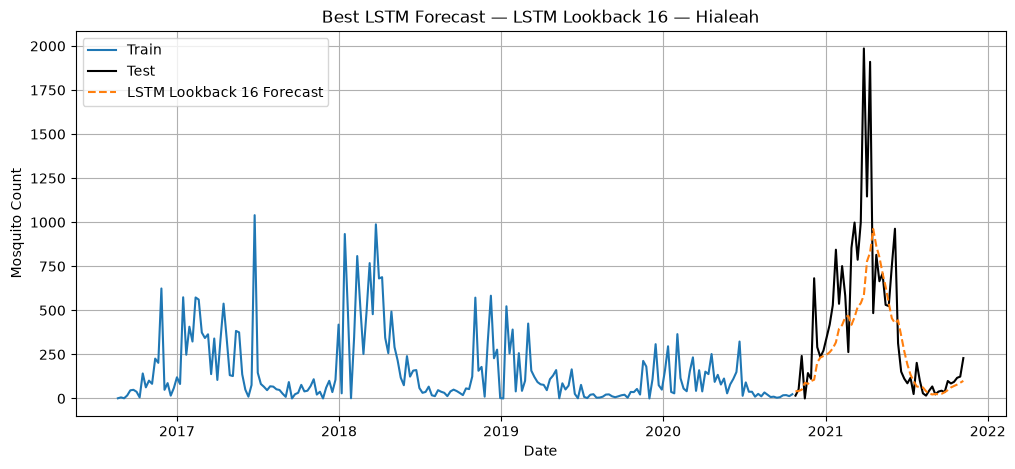

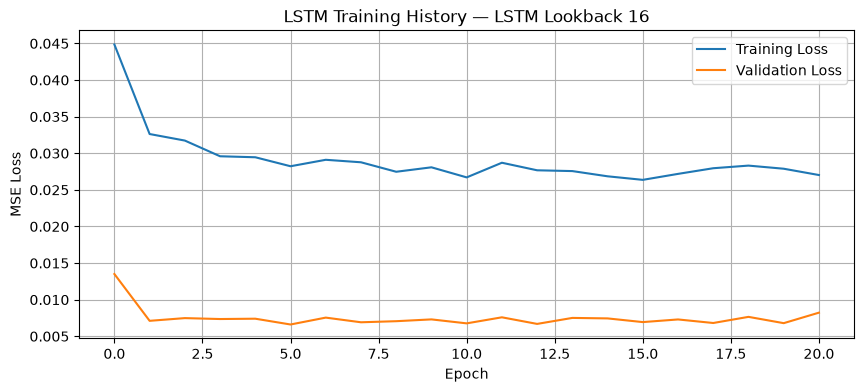

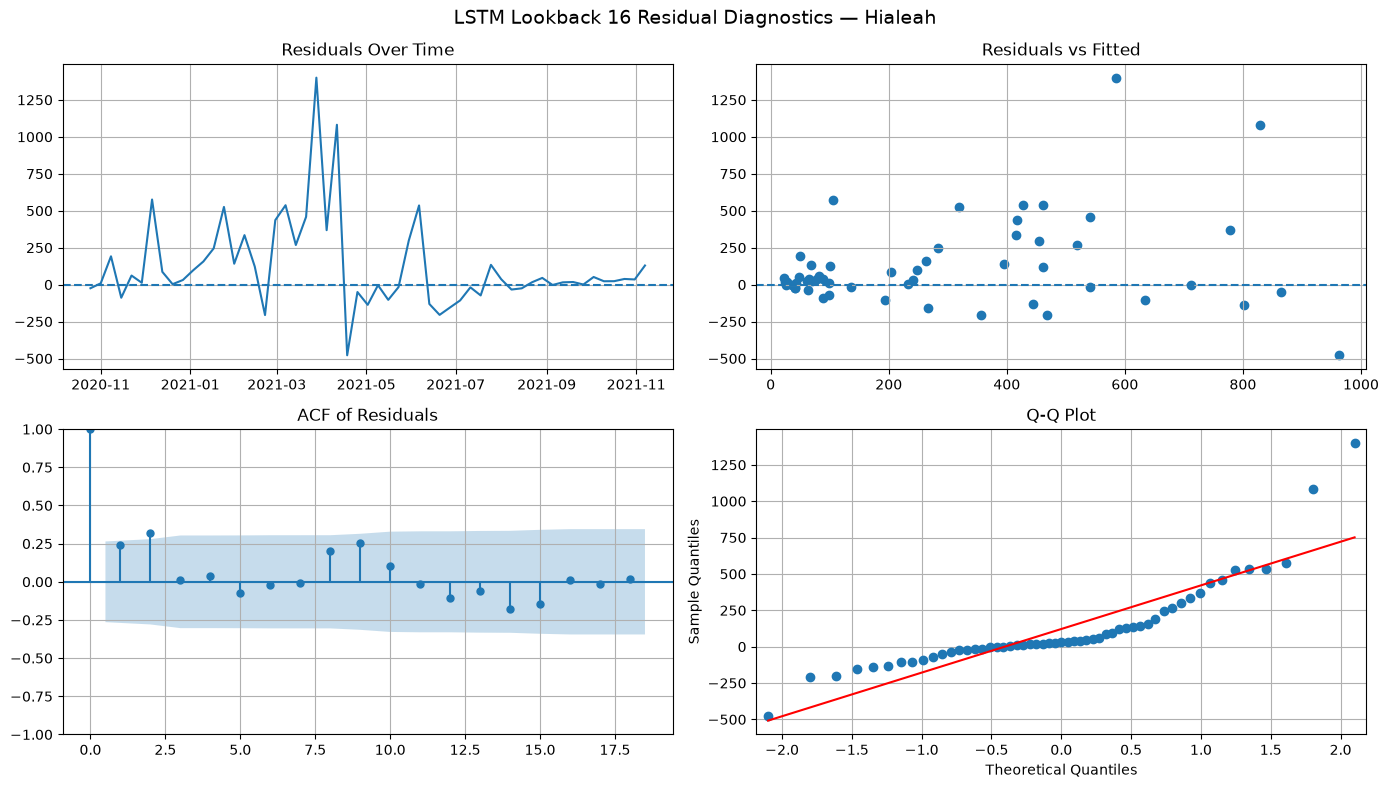

Ljung-Box Test:


,lb_stat,lb_pvalue
10,17.699678,0.060246
20,25.972557,0.166720


{'RMSE': np.float64(323.6132477103948),
 'MAE': 189.1192474712025,
 'R2': 0.4519102846923343,
 'nRMSE': np.float64(0.7878332429210213),
 'MAPE': np.float64(53.722954271822985),
 'SMAPE': np.float64(55.46955068095411)}

In [66]:
best_lstm_name = lstm_results_df.iloc[0]["Model"]
best_lstm_output = lstm_outputs[best_lstm_name]

print("Best LSTM model:", best_lstm_name)
display(lstm_results_df.iloc[[0]])

lstm_test_index = test_series.index

best_lstm_true = pd.Series(
    best_lstm_output["y_true"],
    index=lstm_test_index,
    name="Observed"
)

best_lstm_pred = pd.Series(
    best_lstm_output["y_pred"],
    index=lstm_test_index,
    name="LSTM Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(best_lstm_true.index, best_lstm_true, label="Test", color="black")
plt.plot(
    best_lstm_pred.index,
    best_lstm_pred,
    label=f"{best_lstm_name} Forecast",
    linestyle="--"
)

plt.title(f"Best LSTM Forecast — {best_lstm_name} — Hialeah")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

history = best_lstm_output["history"]

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"LSTM Training History — {best_lstm_name}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

lstm_residuals = best_lstm_true - best_lstm_pred

residual_diagnostics(
    lstm_residuals,
    fitted_values=best_lstm_pred,
    title=f"{best_lstm_name} Residual Diagnostics — Hialeah"
)

add_result(
    best_lstm_name,
    best_lstm_true.values,
    best_lstm_pred.values
)

In [67]:
log_train_series = np.log1p(train_series)
log_test_series = np.log1p(test_series)

log_lstm_results = []
log_lstm_outputs = {}

for config in lstm_configs:
    model_name = "Log-" + config["name"]
    print("Fitting:", model_name)

    try:
        output = fit_evaluate_lstm(
            train_series=log_train_series,
            test_series=log_test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        y_true_original = np.expm1(output["y_true"])
        y_pred_original = np.expm1(output["y_pred"])
        y_pred_original = np.maximum(y_pred_original, 0)

        metrics = compute_metrics(y_true_original, y_pred_original)

        output["y_true_original"] = y_true_original
        output["y_pred_original"] = y_pred_original
        output["metrics_original"] = metrics

        log_lstm_results.append({
            "Model": model_name,
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_lstm_outputs[model_name] = output

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_lstm_results_df = pd.DataFrame(log_lstm_results).sort_values("RMSE").reset_index(drop=True)
log_lstm_results_df

Fitting: Log-LSTM Lookback 4
Log-LSTM Lookback 4 {'RMSE': np.float64(468.8326988046627), 'MAE': 291.61475805802786, 'R2': -0.15036287323561548, 'nRMSE': np.float64(1.141368556757102), 'MAPE': np.float64(65.25575035034132), 'SMAPE': np.float64(85.91904614590234)}
Fitting: Log-LSTM Lookback 8
Log-LSTM Lookback 8 {'RMSE': np.float64(483.7717068442511), 'MAE': 304.7762965462425, 'R2': -0.22484180097888862, 'nRMSE': np.float64(1.1777374237090037), 'MAPE': np.float64(71.20043070223575), 'SMAPE': np.float64(92.9796607987738)}
Fitting: Log-LSTM Lookback 12
Log-LSTM Lookback 12 {'RMSE': np.float64(443.2588401765876), 'MAE': 276.17513032393026, 'R2': -0.02828589913921542, 'nRMSE': np.float64(1.0791092514922236), 'MAPE': np.float64(74.38412795708629), 'SMAPE': np.float64(85.12794916716932)}
Fitting: Log-LSTM Lookback 16
Log-LSTM Lookback 16 {'RMSE': np.float64(441.20699166322356), 'MAE': 270.9639948411422, 'R2': -0.018788046591236007, 'nRMSE': np.float64(1.0741140466305459), 'MAPE': np.float64(65

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-LSTM Lookback 24,24,64,0.3,431.240744,263.731739,0.026718,1.049851,58.829190,86.105232
1,Log-LSTM Lookback 16,16,64,0.2,441.206992,270.963995,-0.018788,1.074114,65.781633,80.664121
2,Log-LSTM Lookback 12,12,64,0.2,443.258840,276.175130,-0.028286,1.079109,74.384128,85.127949
3,Log-LSTM Lookback 4,4,32,0.2,468.832699,291.614758,-0.150363,1.141369,65.255750,85.919046
4,Log-LSTM Lookback 8,8,32,0.2,483.771707,304.776297,-0.224842,1.177737,71.200431,92.979661


In [68]:
all_lstm_results_df = pd.concat(
    [lstm_results_df, log_lstm_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(all_lstm_results_df)

best_overall_lstm_name = all_lstm_results_df.iloc[0]["Model"]

if best_overall_lstm_name.startswith("Log-"):
    best_overall_lstm_output = log_lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true_original"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred_original"],
        index=test_series.index
    )
else:
    best_overall_lstm_output = lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred"],
        index=test_series.index
    )

print("Best overall LSTM model:", best_overall_lstm_name)
display(all_lstm_results_df.iloc[[0]])

add_result(
    best_overall_lstm_name,
    best_overall_lstm_true.values,
    best_overall_lstm_pred.values
)

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 16,16,64,0.2,323.613248,189.119247,0.451910,0.787833,53.722954,55.469551
1,LSTM Lookback 8,8,32,0.2,325.897157,204.720579,0.444147,0.793393,95.193852,60.023276
2,LSTM Lookback 12,12,64,0.2,357.990223,224.265703,0.329280,0.871524,108.232511,66.913784
3,LSTM Lookback 24,24,64,0.3,358.212954,217.082547,0.328445,0.872066,88.504823,63.820967
4,Log-LSTM Lookback 24,24,64,0.3,431.240744,263.731739,0.026718,1.049851,58.829190,86.105232
5,LSTM Lookback 4,4,32,0.2,433.444617,263.833723,0.016745,1.055217,85.339943,74.262919
6,Log-LSTM Lookback 16,16,64,0.2,441.206992,270.963995,-0.018788,1.074114,65.781633,80.664121
7,Log-LSTM Lookback 12,12,64,0.2,443.258840,276.175130,-0.028286,1.079109,74.384128,85.127949
8,Log-LSTM Lookback 4,4,32,0.2,468.832699,291.614758,-0.150363,1.141369,65.255750,85.919046
9,Log-LSTM Lookback 8,8,32,0.2,483.771707,304.776297,-0.224842,1.177737,71.200431,92.979661


Best overall LSTM model: LSTM Lookback 16


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 16,16,64,0.2,323.613248,189.119247,0.45191,0.787833,53.722954,55.469551


{'RMSE': np.float64(323.6132477103948),
 'MAE': 189.1192474712025,
 'R2': 0.4519102846923343,
 'nRMSE': np.float64(0.7878332429210213),
 'MAPE': np.float64(53.722954271822985),
 'SMAPE': np.float64(55.46955068095411)}

In [69]:
final_results_df = pd.DataFrame(model_results)

final_results_df = final_results_df.drop_duplicates(
    subset=["City", "Model"],
    keep="last"
)

final_results_df = final_results_df.sort_values("RMSE").reset_index(drop=True)

display(final_results_df)

final_results_df.to_csv("hialeah_univariate_final_model_summary.csv", index=False)

,City,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Hialeah,Rolling Mean,2.007223e+02,1.142376e+02,5.398545e-01,9.740377e-01,4.927544e+02,65.818080
1,Hialeah,"Rolling ARIMA(4, 0, 3)",2.076512e+02,1.301832e+02,5.075379e-01,1.007661e+00,5.722779e+02,79.136209
2,Hialeah,Naive,2.311755e+02,1.336697e+02,3.896380e-01,1.121817e+00,4.902418e+02,77.129786
3,Hialeah,"Rolling Log-ARIMA(4, 0, 3)",2.423170e+02,1.335104e+02,3.293873e-01,1.175883e+00,3.211611e+02,80.086768
4,Hialeah,LSTM Lookback 16,3.236132e+02,1.891192e+02,4.519103e-01,7.878332e-01,5.372295e+01,55.469551
5,Hialeah,Seasonal Naive,3.325025e+02,1.943394e+02,-2.626813e-01,1.613523e+00,6.100709e+02,101.633941
6,Hialeah,ETS Damped Trend + Add Season,4.654134e+02,2.964590e+02,-1.336445e-01,1.133044e+00,7.553804e+01,107.229271
7,Hialeah,Prophet Flexible Trend,4.741668e+02,2.978835e+02,-1.766882e-01,1.154354e+00,6.768154e+01,106.610423
8,Hialeah,Local Level + Seasonal,4.746277e+02,3.037545e+02,-1.789767e-01,1.155476e+00,7.523552e+01,108.080127
9,Hialeah,"ARIMA(4, 0, 3)",5.097462e+02,3.289681e+02,-3.599000e-01,1.240972e+00,1.308397e+02,97.243694


In [70]:
final_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}"
})

,City,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Hialeah,Rolling Mean,200.72,114.24,0.540,0.974,492.75,65.82
1,Hialeah,"Rolling ARIMA(4, 0, 3)",207.65,130.18,0.508,1.008,572.28,79.14
2,Hialeah,Naive,231.18,133.67,0.390,1.122,490.24,77.13
3,Hialeah,"Rolling Log-ARIMA(4, 0, 3)",242.32,133.51,0.329,1.176,321.16,80.09
4,Hialeah,LSTM Lookback 16,323.61,189.12,0.452,0.788,53.72,55.47
5,Hialeah,Seasonal Naive,332.50,194.34,-0.263,1.614,610.07,101.63
6,Hialeah,ETS Damped Trend + Add Season,465.41,296.46,-0.134,1.133,75.54,107.23
7,Hialeah,Prophet Flexible Trend,474.17,297.88,-0.177,1.154,67.68,106.61
8,Hialeah,Local Level + Seasonal,474.63,303.75,-0.179,1.155,75.24,108.08
9,Hialeah,"ARIMA(4, 0, 3)",509.75,328.97,-0.360,1.241,130.84,97.24


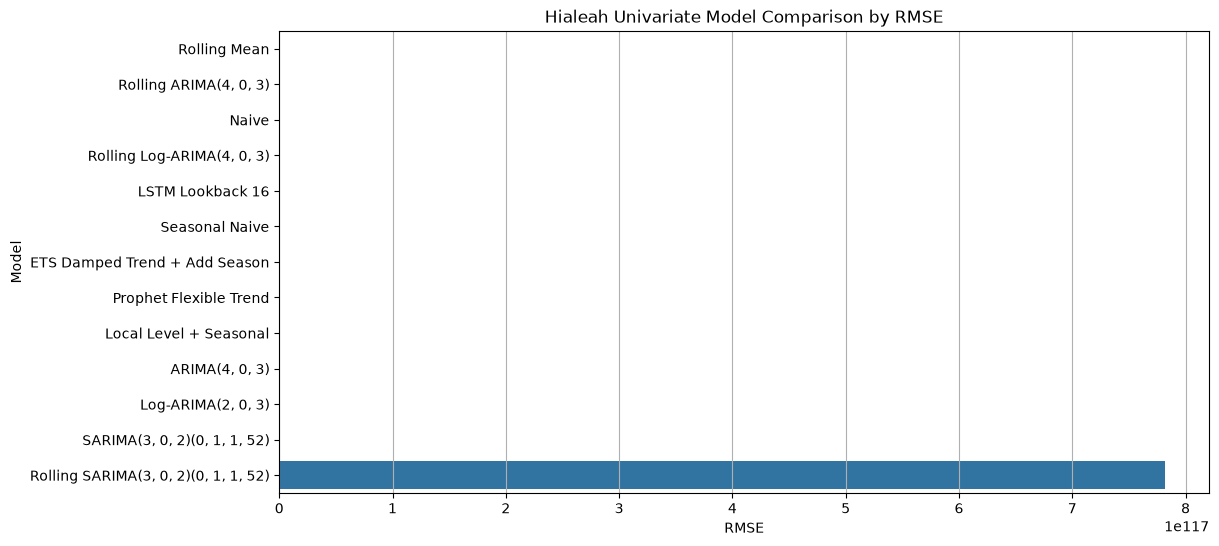

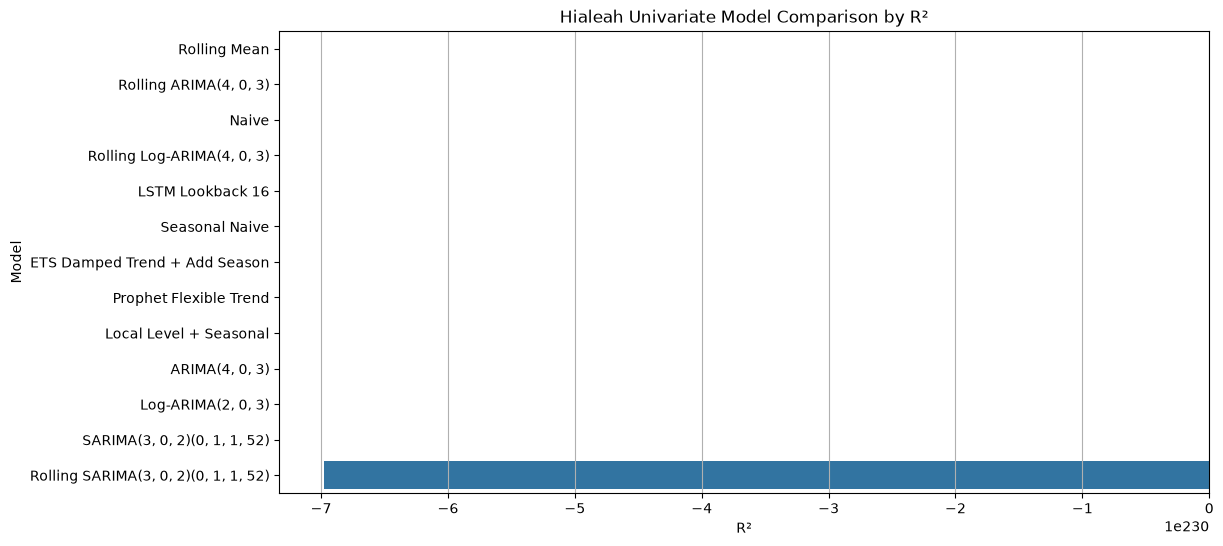

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results_df,
    x="RMSE",
    y="Model"
)

plt.title("Hialeah Univariate Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results_df,
    x="R2",
    y="Model"
)

plt.title("Hialeah Univariate Model Comparison by R²")
plt.xlabel("R²")
plt.ylabel("Model")
plt.show()

In [72]:
# Peak / Outbreak Performance Analysis

def compute_peak_metrics(y_true, y_pred, percentile=90):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    threshold = np.percentile(y_true, percentile)
    peak_mask = y_true >= threshold

    if peak_mask.sum() == 0:
        return {
            "Peak_Threshold": threshold,
            "Peak_RMSE": np.nan,
            "Peak_MAE": np.nan,
            "Peak_Count": 0
        }

    return {
        "Peak_Threshold": threshold,
        "Peak_RMSE": np.sqrt(mean_squared_error(y_true[peak_mask], y_pred[peak_mask])),
        "Peak_MAE": mean_absolute_error(y_true[peak_mask], y_pred[peak_mask]),
        "Peak_Count": peak_mask.sum()
    }


peak_results = []

peak_results.append({
    "Model": f"Rolling ARIMA{best_arima_order}",
    **compute_peak_metrics(y_true_roll_arima, y_pred_roll_arima)
})

peak_results.append({
    "Model": best_overall_ets_name,
    **compute_peak_metrics(test_series.values, best_overall_ets_forecast.values)
})

peak_results.append({
    "Model": best_overall_prophet_name,
    **compute_peak_metrics(test_series.values, best_overall_prophet_test_forecast)
})

peak_results.append({
    "Model": best_overall_lstm_name,
    **compute_peak_metrics(best_overall_lstm_true.values, best_overall_lstm_pred.values)
})

peak_results_df = pd.DataFrame(peak_results).sort_values("Peak_RMSE").reset_index(drop=True)

display(peak_results_df)

,Model,Peak_Threshold,Peak_RMSE,Peak_MAE,Peak_Count
0,"Rolling ARIMA(4, 0, 3)",583.0,477.070526,400.211580,23
1,LSTM Lookback 16,919.4,821.797230,730.319219,6
2,ETS Damped Trend + Add Season,919.4,1161.537519,1062.423710,6
3,Prophet Flexible Trend,919.4,1182.900552,1105.494849,6


In [73]:
peak_results_df.style.format({
    "Peak_Threshold": "{:.2f}",
    "Peak_RMSE": "{:.2f}",
    "Peak_MAE": "{:.2f}",
    "Peak_Count": "{:.0f}"
})

,Model,Peak_Threshold,Peak_RMSE,Peak_MAE,Peak_Count
0,"Rolling ARIMA(4, 0, 3)",583.00,477.07,400.21,23
1,LSTM Lookback 16,919.40,821.80,730.32,6
2,ETS Damped Trend + Add Season,919.40,1161.54,1062.42,6
3,Prophet Flexible Trend,919.40,1182.90,1105.49,6
